# VAYU - Predictive Modeling and Unsupervised Clustering of Ambient Air Quality Across Indian Urban Centres

**Dataset:** CPCB (Central Pollution Control Board) Sensor Data  
**Pipeline:** Data Cleaning → Regression → Classification → Clustering → Dimensionality Reduction

## Problem Statement

Air pollution is one of the most critical public health challenges in India. 
The Central Pollution Control Board (CPCB) operates a nationwide network of 
Continuous Ambient Air Quality Monitoring Stations (CAAQMS) that record 
concentrations of six key pollutants — PM2.5, PM10, NO2, SO2, CO, and O3 — 
on an hourly basis across Indian cities.

Despite the scale of this data collection effort, two fundamental challenges remain:

**1. Prediction (Supervised Learning)**  
Given the current pollutant concentrations and time context, can we accurately 
predict how bad the air quality is — either as a precise number (AQI) or as a 
human-interpretable category (Good / Moderate / Severe)?

**2. Pattern Discovery (Unsupervised Learning)**  
Without any labels, can we discover natural groupings among Indian cities based 
on their long-term pollution signatures — identifying which cities share similar 
chronic pollution patterns, seasonal behaviour, and dominant pollutants?

---

### Formal Problem Definitions

| Task | Type | Input | Output |
|---|---|---|---|
| **Task 1** | Regression | PM2.5, PM10, NO2, SO2, CO, O3 + time features | AQI as a continuous number (0–500) |
| **Task 2** | Classification | Same pollutant + time features + city | AQI category label: Good / Satisfactory / Moderate / Poor / Very Poor / Severe |
| **Task 3** | Clustering | City-level aggregated AQI profile (mean, std, seasonal means, pollutant dominance) | Cluster assignment — which cities are pollution-similar? |
| **Task 4** | Dimensionality Reduction | 6-dimensional pollutant matrix (842k rows) | 2D representation preserving pollutant co-occurrence structure |

---

### Why This Problem Matters

- India has **14 of the world's 20 most polluted cities** (IQAir 2023)
- CPCB's AQI threshold of 200 (Moderate) triggers public health advisories
- Predicting AQI from raw sensor readings enables **early warning systems**
- Clustering cities by pollution signature enables **targeted policy interventions** — 
  PM2.5-heavy northern cities need different solutions than ozone-heavy southern cities

---

### Scope of This Notebook

This notebook covers **Step 1 of the pipeline: Data Understanding and Cleaning**.

Before any model can be trained, the raw CPCB data must be:
1. Audited for structural issues (wrong dtypes, sentinel values, impossible readings)
2. Cleaned systematically (7 operations in defined order)
3. Validated — distributions before vs after cleaning must be compared

The output of this notebook is `master_cleaned.csv` — the single source of truth 
that feeds all four ML tasks above.

## Dataset

### Primary Source — `aqi_india_38cols_knn_final.csv`

| Property | Value |
|---|---|
| Rows | 842,160 |
| Cities | 29 Indian cities |
| Time range | 2015 – 2024 (hourly) |
| Pollutants | PM2.5, PM10, NO2, SO2, CO, O3 |
| Pre-processing | KNN-imputed — 0% standard NaN |
| Known issue | Sentinel value **999** used by CPCB to flag sensor errors |

### Secondary Source — 277 `*_AQIBulletins.csv` files

| Property | Value |
|---|---|
| Files | 277 (one per city) |
| Cities covered | 277 Indian cities |
| Data type | Daily aggregated AQI only (no raw pollutant readings) |
| Used for | K-Means clustering task only |

### Why These Sources Were Chosen

The primary file was selected from a scan of **299 raw files** because it is the only 
file that combines all of: 842k rows of depth, all 6 CPCB pollutants, 9 years of 
temporal coverage, and 29 cities in a single consistent schema.

The bulletin files were chosen for clustering because they cover **277 cities** — 
giving far richer geographic spread than the 29-city primary file.

## Data Access

This notebook pulls data directly from two HuggingFace dataset repositories:

| Repository | Contents | Path after download |
|---|---|---|
| `rachitgoyell/vayu-raw` | 299 raw CPCB CSV files | `./data/` |
| `rachitgoyell/vayu-cleaned` | Cleaned, model-ready outputs | `./data/cleaned/` |

The download cell below sets up the exact folder structure the pipeline expects.  
No manual downloading or path changes are needed — just run the cell.

> **Note:** Both repositories are public. No HuggingFace token is required.

In [3]:
# ── HuggingFace Dataset Setup ────────────────────────────────────────────────
import os
from huggingface_hub import snapshot_download

HF_USERNAME = "rachitgoyell"

# Download raw data → ./data/
snapshot_download(
    repo_id   = f"{HF_USERNAME}/vayu-raw",
    repo_type = "dataset",
    local_dir = "./data/raw"
)

# Download cleaned data → ./data/cleaned/
snapshot_download(
    repo_id   = f"{HF_USERNAME}/vayu-cleaned",
    repo_type = "dataset",
    local_dir = "./data/cleaned"
)

DATA_ROOT   = './data'
OUTPUT_ROOT = './data/cleaned'

print("✓ data/         — raw files ready")
print("✓ data/cleaned/ — cleaned files ready")

Fetching 301 files:  10%|▉         | 30/301 [00:04<00:42,  6.36it/s]


KeyboardInterrupt: 

## Dataset Audit — File Inventory and Selection Rationale

Before loading any data, we scan every file in the raw data folder to understand what we are working with. This step answers three questions:

1. How many files exist, and what schemas do they follow?
2. Which files are suitable for each ML task, and why?
3. Which files are rejected, and what specifically makes them unusable?

This is not just bookkeeping. Choosing the wrong source file is the most common cause of silent errors in ML pipelines — a file with the right column names but only 200 rows, or a file where 92% of cells are empty, will produce a model that appears to train correctly but is statistically meaningless.

### File Classification Schema

| Schema | Description | Decision |
|---|---|---|
| Multi-city Historical | 842k rows, all 6 pollutants, 29 cities, 2022–2025 | **PRIMARY** — regression, classification, dimensionality reduction |
| AQI Bulletin CSVs | One file per city, daily AQI only, 277 cities | **SECONDARY** — clustering only |
| API Snapshots | 200-row exports from OpenAQ/CPCB API | **REJECTED** — insufficient rows |
| Single Station Hourly | Raw CAAQMS exports, no city column | **REJECTED** — cannot be joined |
| Small Academic Datasets | 153–200 row manually compiled files | **REJECTED** — insufficient rows |
| Malformed / Corrupted | 92% null or wrong schema | **REJECTED** — unreadable |

Total raw source files found : 300

  FILE AUDIT SUMMARY
  Total source files scanned : 300
  Accepted                   : 278
    — Primary dataset        : 1
    — AQI Bulletin files     : 277
  Rejected                   : 22

  Rejected breakdown:
    API Snapshot                   : 9 files
    Malformed / Corrupted          : 2 files
    Single Station Hourly          : 6 files
    Small Academic Dataset         : 5 files

  Rejection reasons:
    3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv      → Only 200 rows — point-in-time API export, not a time series
    AP001.csv                                     → Only 200 rows — point-in-time API export, not a time series
    AQI Data.csv                                  → No pollutant or AQI columns found
    AQI.csv                                       → Only 200 rows — point-in-time API export, not a time series
    AshokVihar_Hourly.csv                         → No city column — cannot identify geographic source
    Cleaned_NSUT.xlsx

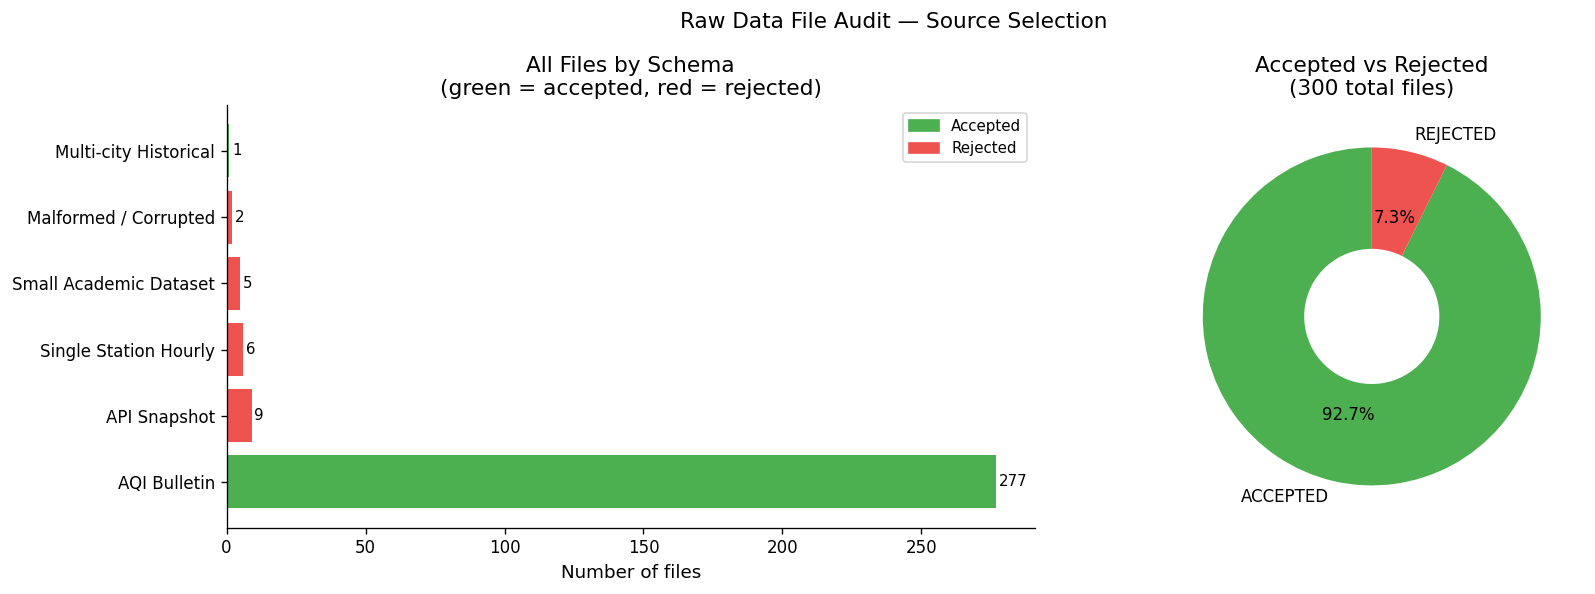

In [4]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11

DATA_ROOT = './data/raw'

# ── Keywords for schema classification ───────────────────────────────────────
PRIMARY_FILE      = 'aqi_india_38cols_knn_final.csv'
BULLETIN_PATTERN  = 'AQIBulletins'
POLLUTANT_KW      = ['pm2', 'pm10', 'no2', 'so2', 'co', 'o3']
BULLETIN_KW       = ['index', 'air', 'quality', 'pollutant']
PIPELINE_DIRS     = ['cleaned']          # our own output folders — exclude from audit

# ── Collect all CSV and XLSX files ────────────────────────────────────────────
all_files = (
    glob.glob(os.path.join(DATA_ROOT, '**/*.csv'),  recursive=True) +
    glob.glob(os.path.join(DATA_ROOT, '**/*.xlsx'), recursive=True)
)

# Exclude files inside our own pipeline output directories
all_files = [
    fp for fp in all_files
    if not any(pd.io.common.stringify_path(fp).replace('\\', '/')
               .split('data/')[-1].startswith(d) for d in PIPELINE_DIRS)
]

print(f'Total raw source files found : {len(all_files)}')

# ── Classify each file ────────────────────────────────────────────────────────
results = []

for fp in sorted(all_files):
    fname  = os.path.basename(fp)
    rel    = os.path.relpath(fp, DATA_ROOT)

    # ── Known accepted files ──────────────────────────────────────────────────
    if PRIMARY_FILE in fname:
        results.append({
            'file'    : rel,
            'schema'  : 'Multi-city Historical',
            'status'  : 'ACCEPTED',
            'used_for': 'Regression, Classification, Dimensionality Reduction',
            'reason'  : 'Only file with 842k rows + all 6 pollutants + 29 cities',
            'rows'    : 842160,
            'cols'    : 31
        })
        continue

    if BULLETIN_PATTERN in fname:
        results.append({
            'file'    : rel,
            'schema'  : 'AQI Bulletin',
            'status'  : 'ACCEPTED',
            'used_for': 'K-Means Clustering',
            'reason'  : 'Daily AQI history — 277 cities for geographic clustering',
            'rows'    : '~1,000',
            'cols'    : 6
        })
        continue

    # ── Read first 200 rows to inspect ───────────────────────────────────────
    try:
        df_sample = (
            pd.read_excel(fp, nrows=200)
            if fname.endswith('.xlsx')
            else pd.read_csv(fp, nrows=200, low_memory=False, encoding_errors='replace')
        )

        col_str   = ' '.join(c.lower() for c in df_sample.columns)
        null_pct  = df_sample.isnull().mean().mean() * 100
        n_rows    = len(df_sample)
        n_cols    = len(df_sample.columns)

        has_pollutants = any(k in col_str for k in POLLUTANT_KW)
        has_bulletin   = any(k in col_str for k in BULLETIN_KW)
        has_city       = any(k in col_str for k in ['city', 'station', 'location'])
        has_date       = any(k in col_str for k in ['date', 'time', 'datetime'])

        # ── Rejection logic ───────────────────────────────────────────────────
        if null_pct > 80:
            schema = 'Malformed / Corrupted'
            reason = f'{null_pct:.0f}% cells empty — file is essentially blank'

        elif not has_date and not has_city and has_pollutants:
            schema = 'Single Station Hourly'
            reason = 'No city column — cannot identify geographic source'

        elif not has_pollutants and not has_bulletin:
            schema = 'Malformed / Corrupted'
            reason = 'No pollutant or AQI columns found'

        elif has_pollutants and n_rows < 10000:
            if any(k in fname.lower() for k in ['dataset', 'cleaned', 'nsut']):
                schema = 'Small Academic Dataset'
                reason = f'Only {n_rows} rows — manually compiled research file'
            else:
                schema = 'API Snapshot'
                reason = f'Only {n_rows} rows — point-in-time API export, not a time series'

        else:
            schema = 'Unknown'
            reason = 'Schema does not match any expected format'

        results.append({
            'file'    : rel,
            'schema'  : schema,
            'status'  : 'REJECTED',
            'used_for': '—',
            'reason'  : reason,
            'rows'    : n_rows,
            'cols'    : n_cols
        })

    except Exception as e:
        results.append({
            'file'    : rel,
            'schema'  : 'Malformed / Corrupted',
            'status'  : 'REJECTED',
            'used_for': '—',
            'reason'  : f'Cannot be read: {str(e)[:80]}',
            'rows'    : 'ERR',
            'cols'    : 'ERR'
        })

# ── Build summary dataframe ───────────────────────────────────────────────────
audit_df = pd.DataFrame(results)

accepted = audit_df[audit_df['status'] == 'ACCEPTED']
rejected = audit_df[audit_df['status'] == 'REJECTED']

# ── Print summary ─────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print(f'  FILE AUDIT SUMMARY')
print(f'{"="*60}')
print(f'  Total source files scanned : {len(audit_df)}')
print(f'  Accepted                   : {len(accepted)}')
print(f'    — Primary dataset        : 1')
print(f'    — AQI Bulletin files     : {len(accepted) - 1}')
print(f'  Rejected                   : {len(rejected)}')

print(f'\n  Rejected breakdown:')
for schema, grp in rejected.groupby('schema'):
    print(f'    {schema:<30} : {len(grp)} files')

print(f'\n  Rejection reasons:')
for _, row in rejected[rejected['schema'] != 'AQI Bulletin'].iterrows():
    print(f'    {row["file"]:<45} → {row["reason"]}')

# ── Visualisation ─────────────────────────────────────────────────────────────
schema_counts = audit_df.groupby(['schema', 'status']).size().unstack(fill_value=0)

accepted_counts = audit_df[audit_df['status'] == 'ACCEPTED']['schema'].value_counts()
rejected_counts = audit_df[audit_df['status'] == 'REJECTED']['schema'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: all files by schema
all_schema = audit_df['schema'].value_counts()
colors_schema = [
    '#4CAF50' if s in ['Multi-city Historical', 'AQI Bulletin']
    else '#EF5350'
    for s in all_schema.index
]
bars = axes[0].barh(all_schema.index, all_schema.values, color=colors_schema)
for bar, val in zip(bars, all_schema.values):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)
axes[0].set_xlabel('Number of files')
axes[0].set_title('All Files by Schema\n(green = accepted, red = rejected)')
green_p = mpatches.Patch(color='#4CAF50', label='Accepted')
red_p   = mpatches.Patch(color='#EF5350', label='Rejected')
axes[0].legend(handles=[green_p, red_p], fontsize=9)

# Right: pie of accepted vs rejected
status_counts = audit_df['status'].value_counts()
axes[1].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=['#4CAF50', '#EF5350'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
axes[1].set_title(f'Accepted vs Rejected\n({len(audit_df)} total files)')

plt.suptitle('Raw Data File Audit — Source Selection', fontsize=13)
plt.tight_layout()
plt.show()

## Primary Dataset — Exploratory Data Analysis

All four supervised and unsupervised tasks in this project trace back to a single
source file: `aqi_india_38cols_knn_final.csv`. Before any cleaning or modelling,
we need to fully understand what this file contains, what problems it has, and
what decisions those problems will force us to make downstream.

This section follows a strict rule: **no data is modified here**. Every operation
is read-only. We look, measure, and document. The actual fixes happen in the
cleaning section that follows.

### What We Are Looking For

| Check | Why It Matters |
|---|---|
| Shape and memory | Confirms the file loaded correctly and sets expectations |
| Column types | Text columns cannot go into models — must be encoded first |
| Standard NaN values | pandas `isnull()` — imputation or row removal needed |
| Sentinel value 999 | CPCB-specific error code — invisible to `isnull()`, needs manual detection |
| Pollutant distributions | Are readings physically plausible? Skew tells us if log-transform is needed |
| City balance | Unequal city representation requires stratified sampling |
| Temporal coverage | Gaps in years or months affect seasonal feature validity |
| Correlation structure | High inter-pollutant correlation signals multicollinearity risk |
| Target variable balance | Class imbalance in AQI_category determines if SMOTE is needed |


---

> **Note on KNN imputation:** This file was pre-processed before being published.
> All standard NaN values from sensor dropouts were filled using K-Nearest Neighbour
> imputation — each missing reading was estimated from the K most similar rows.
> This is why `isnull()` returns near-zero counts. However, the CPCB sentinel
> value **999** — which the original system recorded when a sensor went offline —
> survived imputation because pandas treats it as a valid integer, not a missing value.
> Detecting and removing it is the first job of the cleaning pipeline.

### Section 1 — Load Dataset and Column Inventory

The first code cell does three things in one pass: loads the file, reports its
shape and memory footprint, and classifies every column into one of four roles.

Column role classification matters because different roles require different
treatment before modelling:

- **POLLUTANT** columns are the core input features — they go into every model
- **TARGET** columns are what we predict — never used as input features
- **IDENTITY** columns (city, state, coordinates) are metadata — need encoding or exclusion
- **DATETIME** columns drive temporal features — need parsing before use
- **OTHER** columns are weather variables — candidates for feature selection later

The dtype audit runs alongside this — any numeric column stored as `object`
(string) would silently break correlation and range checks downstream.

Loading: ./data/raw/aqi_india_38cols_knn_final.csv
This may take ~15 seconds for 842k rows...

Shape   : 842,160 rows  x  31 columns
Memory  : 548.0 MB

Pollutant cols : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'pm25_category_india']
City col       : city
Date col       : datetime
AQI numeric    : None
AQI category   : aqi_category

  COLUMN INVENTORY


,column,role,dtype,nulls,sample
0,city,IDENTITY,str,0,agartala
1,state,IDENTITY,str,0,tripura
2,latitude,IDENTITY,float64,0,23.8315
3,longitude,IDENTITY,float64,0,91.2868
4,datetime,DATETIME,str,0,2022-08-05 00:00:00
5,month,DATETIME,float64,0,8.0
6,day_name,DATETIME,str,0,friday
7,is_weekend,DATETIME,bool,0,False
8,season,DATETIME,str,0,monsoon
9,time_of_day,DATETIME,str,0,night


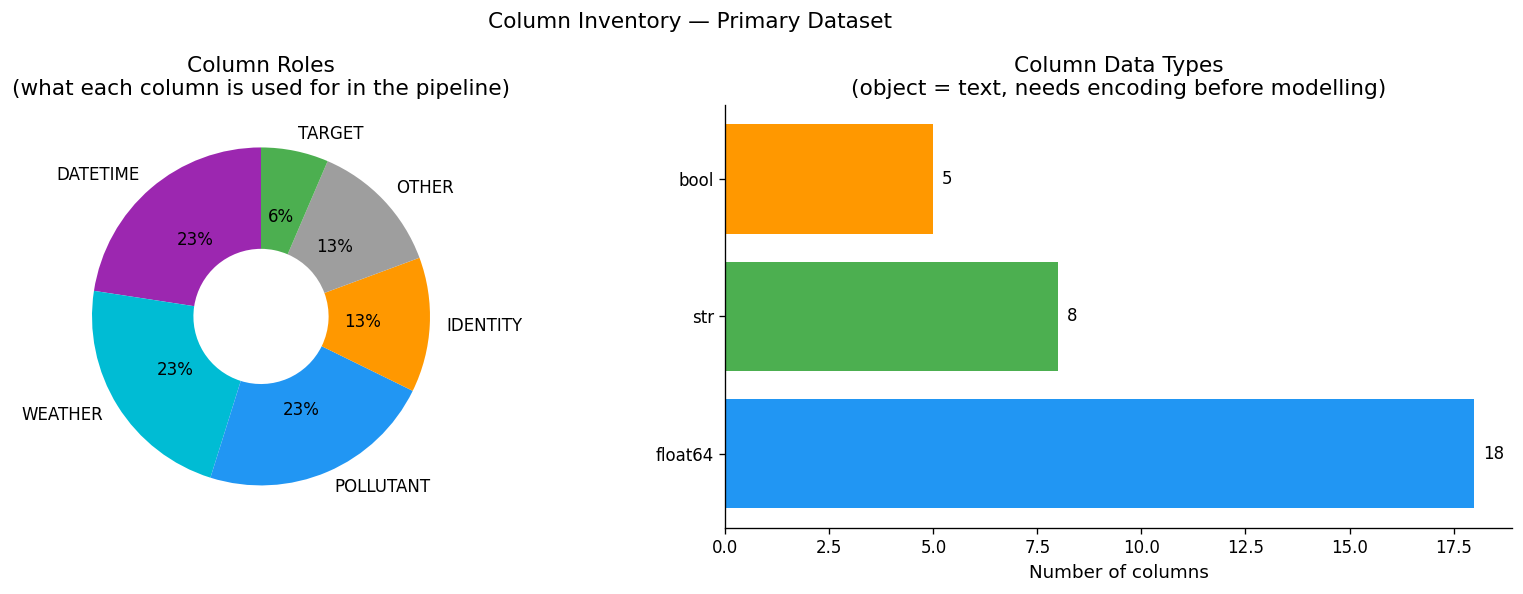


COLUMN ROLE SUMMARY:
  [POLLUTANT ]  7 cols — ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'pm25_category_india']
  [TARGET    ]  2 cols — ['us_aqi', 'aqi_category']
  [IDENTITY  ]  4 cols — ['city', 'state', 'latitude', 'longitude']
  [DATETIME  ]  7 cols — ['datetime', 'month', 'day_name', 'is_weekend', 'season', 'time_of_day', 'crop_burning_season']
  [WEATHER   ]  7 cols — ['humidity_percent', 'dew_point_c', 'wind_gusts_kmh', 'is_raining', 'heavy_rain', 'pressure_msl_hpa', 'cloud_cover_percent']
  [OTHER     ]  4 cols — ['precipitation_mm', 'dust_ugm3', 'aod', 'festival_period']


In [5]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
sns.set_palette('muted')

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 40)

DATA_ROOT   = './data/raw'
OUTPUT_ROOT = './data/cleaned'
PRIMARY_FILE = os.path.join(DATA_ROOT, 'aqi_india_38cols_knn_final.csv')

# ── Load ──────────────────────────────────────────────────────────────────────
print(f'Loading: {PRIMARY_FILE}')
print('This may take ~15 seconds for 842k rows...\n')

df = pd.read_csv(PRIMARY_FILE, low_memory=False)

print(f'Shape   : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

# ── Column role classification ────────────────────────────────────────────────
POLLUTANT_KW = ['pm2', 'pm10', 'no2', 'so2', 'co_', 'o3', 'ozone', 'nh3', 'nox']
TARGET_KW    = ['aqi', 'category', 'bucket', 'index']
IDENTITY_KW  = ['city', 'state', 'station', 'lat', 'lon', 'location']
DATETIME_KW  = ['date', 'time', 'year', 'month', 'day', 'hour', 'week', 'season']
WEATHER_KW   = ['humidity', 'temp', 'pressure', 'wind', 'rain',
                'cloud', 'dew', 'solar', 'visibility', 'uv']

EXCLUDE_KW   = ['cloud', 'cover', 'humidity', 'temp', 'pressure',
                'wind', 'rain', 'solar', 'visibility', 'dew', 'uv']

col_roles = {}
for col in df.columns:
    cl = col.lower()
    if   any(k in cl for k in POLLUTANT_KW) and not any(e in cl for e in EXCLUDE_KW):
        col_roles[col] = 'POLLUTANT'
    elif any(k in cl for k in TARGET_KW):    col_roles[col] = 'TARGET'
    elif any(k in cl for k in IDENTITY_KW):  col_roles[col] = 'IDENTITY'
    elif any(k in cl for k in DATETIME_KW):  col_roles[col] = 'DATETIME'
    elif any(k in cl for k in WEATHER_KW):   col_roles[col] = 'WEATHER'
    else:                                    col_roles[col] = 'OTHER'

# ── Detected key columns ──────────────────────────────────────────────────────
pollutant_cols = [c for c, r in col_roles.items() if r == 'POLLUTANT']
city_col       = next((c for c in df.columns if c.lower() in ['city', 'city_name']), None)
date_col       = next((c for c in df.columns
                       if 'datetime' in c.lower() or c.lower() == 'date'
                       or 'timestamp' in c.lower()), None)
aqi_col        = next((c for c in df.columns
                       if c.lower() in ['aqi', 'air_quality_index']), None)
cat_col        = next((c for c in df.columns
                       if 'category' in c.lower() or 'bucket' in c.lower()), None)

print(f'\nPollutant cols : {pollutant_cols}')
print(f'City col       : {city_col}')
print(f'Date col       : {date_col}')
print(f'AQI numeric    : {aqi_col}')
print(f'AQI category   : {cat_col}')

# ── Column inventory table ────────────────────────────────────────────────────
print(f'\n{"="*70}')
print('  COLUMN INVENTORY')
print(f'{"="*70}')

inv_rows = []
for col in df.columns:
    role    = col_roles.get(col, 'OTHER')
    dtype   = str(df[col].dtype)
    nulls   = df[col].isnull().sum()
    sample  = str(df[col].dropna().iloc[0]) if df[col].notna().any() else 'N/A'
    inv_rows.append({'column': col, 'role': role,
                     'dtype': dtype, 'nulls': nulls, 'sample': sample[:30]})

inv_df = pd.DataFrame(inv_rows)
display(inv_df)

# ── Role distribution chart ───────────────────────────────────────────────────
role_colors = {
    'POLLUTANT': '#2196F3',
    'TARGET'   : '#4CAF50',
    'IDENTITY' : '#FF9800',
    'DATETIME' : '#9C27B0',
    'WEATHER'  : '#00BCD4',
    'OTHER'    : '#9E9E9E',
}

role_counts = pd.Series(col_roles).value_counts()
dtype_counts = df.dtypes.astype(str).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: role pie
axes[0].pie(
    role_counts.values,
    labels=role_counts.index,
    colors=[role_colors[r] for r in role_counts.index],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
axes[0].set_title('Column Roles\n(what each column is used for in the pipeline)')

# Right: dtype bar
dtype_palette = ['#2196F3', '#4CAF50', '#FF9800', '#9E9E9E']
bars = axes[1].barh(
    dtype_counts.index,
    dtype_counts.values,
    color=dtype_palette[:len(dtype_counts)]
)
for bar, val in zip(bars, dtype_counts.values):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10)
axes[1].set_xlabel('Number of columns')
axes[1].set_title('Column Data Types\n(object = text, needs encoding before modelling)')

plt.suptitle('Column Inventory — Primary Dataset', fontsize=13)
plt.tight_layout()
plt.show()

# ── Role summary printout ─────────────────────────────────────────────────────
print('\nCOLUMN ROLE SUMMARY:')
for role in ['POLLUTANT', 'TARGET', 'IDENTITY', 'DATETIME', 'WEATHER', 'OTHER']:
    cols_in_role = [c for c, r in col_roles.items() if r == role]
    if cols_in_role:
        print(f'  [{role:<10}] {len(cols_in_role):>2} cols — {cols_in_role}')

### A Note on Pollutant Column Detection — The CO / cloud_cover Bug

A subtle but critical bug exists in naive pollutant detection code that uses
`'co'` as a keyword. The column `cloud_cover_percent` contains the substring
`'co'` and would be incorrectly classified as a pollutant column.

This matters for two reasons:

1. **Range validation** — if `cloud_cover_percent` is treated as a pollutant,
   it would be subject to CO's valid range check of `(0, 50000)`. Cloud cover
   is a percentage (0–100), so nothing would be flagged, but the column would
   be forward-filled during sensor gap repair — corrupting weather data.

2. **Correlation analysis** — including a weather column in the pollutant
   correlation matrix would produce meaningless cross-correlations and
   potentially mislead feature selection.

**Fix applied — two layers of protection:**
```python
# Layer 1: keyword requires underscore boundary
POLLUTANT_KW = ['co_', ...]   # matches co_ugm3, NOT cloud_cover_percent

# Layer 2: explicit exclude list as second guard
EXCLUDE_KW = ['cloud', 'cover', 'humidity', ...]
# column must pass BOTH checks to be classified as POLLUTANT
```

This ensures `cloud_cover_percent` is correctly classified as WEATHER
and `co_ugm3` is correctly classified as POLLUTANT.

### Section 2 — Missing Value Audit and Sentinel 999 Detection

There are two completely different kinds of missing data in this file, and they
require two completely different detection methods.

**Standard NaN** — pandas recognises these as missing. `df.isnull()` catches
them. This file was KNN-imputed before publication, so NaN counts should be
near zero.

**Sentinel value 999** — CPCB records exactly `999` when a sensor goes offline
or produces an out-of-range reading. This is a domain-specific convention, not
a standard missing value marker. pandas treats 999 as a perfectly valid integer.
`isnull()` is completely blind to it. The only way to find it is to know your
domain and check for it explicitly.

If sentinel 999 is left in the dataset:

- A regression model will learn that PM2.5 = 999 predicts some AQI value,
  which is physically impossible — PM2.5 has never reached 999 µg/m³ even
  in the worst recorded pollution events in India
- The correlation matrix computed in the next section will be distorted
- Range validation in the cleaning step will miss it because 999 falls within
  the CO valid range of (0, 50000)

This section quantifies exactly how many sentinel values exist and in which
columns, so the cleaning step can target them precisely.

  MISSING DATA AUDIT
  Standard NaN values   : 2
  Columns with NaN      : 1
  Sentinel 999 values   : 1,477
  Columns with 999      : 2

  Columns with standard NaN:
    pm25_category_india                 0.000%

  Sentinel 999 per pollutant column:
    pm2_5_ugm3                                 0  (0.00%)
    pm10_ugm3                                  0  (0.00%)
    co_ugm3                                  124  (0.01%)  <- needs fixing
    no2_ugm3                                   0  (0.00%)
    so2_ugm3                                   0  (0.00%)
    o3_ugm3                                    0  (0.00%)
    pm25_category_india                        0  (0.00%)

  Sentinel 999 across ALL numeric columns:
    pressure_msl_hpa                       1,353  (0.16%)  (non-pollutant — check if real value)
    co_ugm3                                  124  (0.01%)  (pollutant)


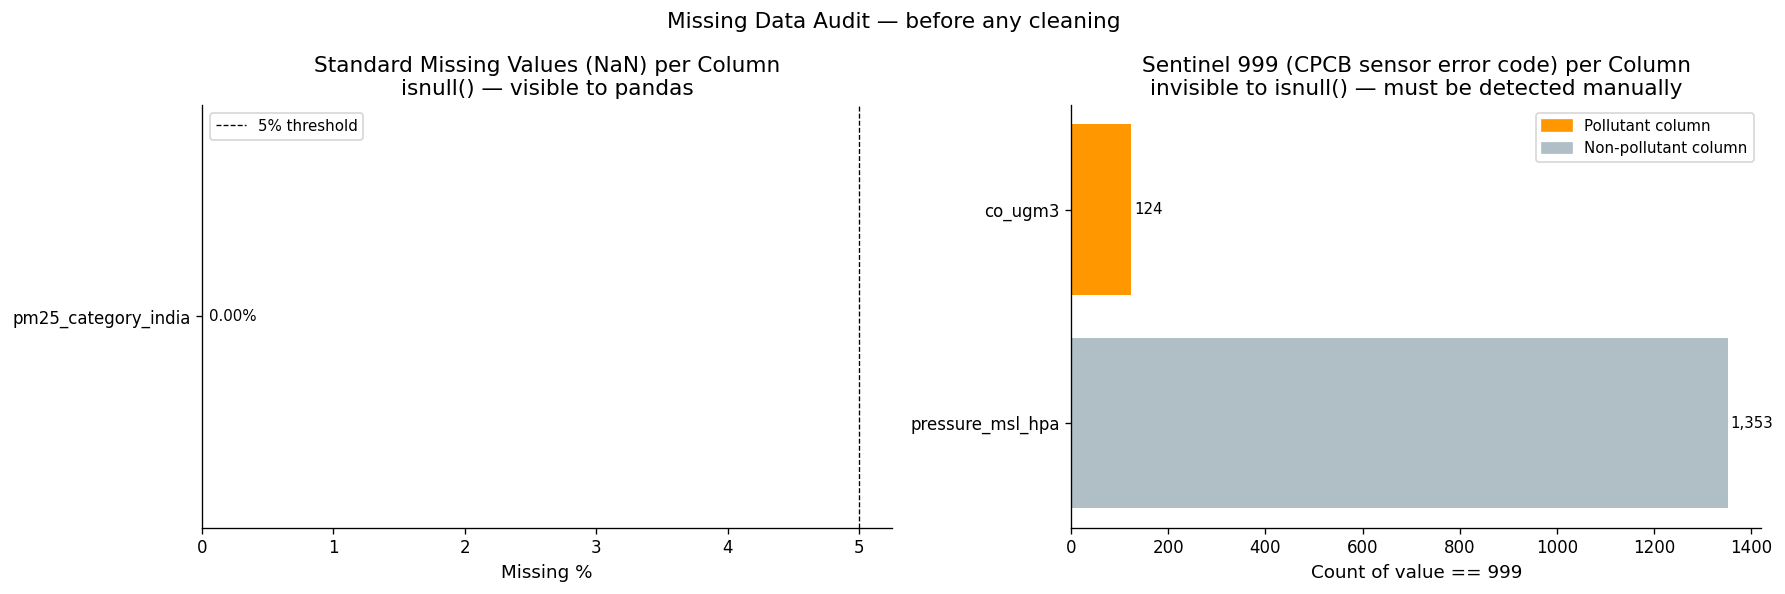


Key variables set for downstream use:
  pollutant_cols   = ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'pm25_category_india']
  city_col         = city
  date_col         = datetime
  cat_col          = aqi_category
  df_raw_snapshot  = frozen copy of pollutant cols before cleaning


In [6]:
# ── Standard NaN audit ────────────────────────────────────────────────────────
null_pct    = df.isnull().mean() * 100
null_pct    = null_pct[null_pct > 0].sort_values(ascending=False)
null_total  = df.isnull().sum().sum()

# ── Sentinel 999 audit ────────────────────────────────────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns

sentinel_counts = {}
for col in numeric_cols:
    count = (pd.to_numeric(df[col], errors='coerce') == 999).sum()
    if count > 0:
        sentinel_counts[col] = count

sentinel_series = pd.Series(sentinel_counts).sort_values(ascending=False)
sentinel_total  = sentinel_series.sum()

# ── Snapshot raw pollutant data before any cleaning ───────────────────────────
# This frozen copy is used later for before/after comparison plots
df_raw_snapshot = df[pollutant_cols].copy()

# ── Printout ──────────────────────────────────────────────────────────────────
print(f'{"="*60}')
print(f'  MISSING DATA AUDIT')
print(f'{"="*60}')
print(f'  Standard NaN values   : {null_total:,}')
print(f'  Columns with NaN      : {len(null_pct)}')
print(f'  Sentinel 999 values   : {sentinel_total:,}')
print(f'  Columns with 999      : {len(sentinel_series)}')

if len(null_pct) > 0:
    print(f'\n  Columns with standard NaN:')
    for col, pct in null_pct.items():
        print(f'    {col:<35} {pct:.3f}%')

print(f'\n  Sentinel 999 per pollutant column:')
for col in pollutant_cols:
    count = (pd.to_numeric(df[col], errors='coerce') == 999).sum()
    pct   = count / len(df) * 100
    flag  = '  <- needs fixing' if count > 0 else ''
    print(f'    {col:<35} {count:>8,}  ({pct:.2f}%){flag}')

print(f'\n  Sentinel 999 across ALL numeric columns:')
if len(sentinel_series) > 0:
    for col, count in sentinel_series.items():
        pct  = count / len(df) * 100
        note = '(pollutant)' if col in pollutant_cols else '(non-pollutant — check if real value)'
        print(f'    {col:<35} {count:>8,}  ({pct:.2f}%)  {note}')
else:
    print('    None found.')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: standard NaN
if len(null_pct) > 0:
    bars = axes[0].barh(null_pct.index, null_pct.values, color='#EF5350')
    axes[0].axvline(5, color='black', linestyle='--',
                    linewidth=0.8, label='5% threshold')
    axes[0].set_xlabel('Missing %')
    axes[0].legend(fontsize=9)
    for bar, val in zip(bars, null_pct.values):
        axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                     f'{val:.2f}%', va='center', fontsize=9)
else:
    axes[0].text(0.5, 0.5,
                 'No standard NaN found\n(file was KNN-imputed before publication)',
                 ha='center', va='center', fontsize=11,
                 transform=axes[0].transAxes, color='green')
axes[0].set_title('Standard Missing Values (NaN) per Column\nisnull() — visible to pandas')

# Right: sentinel 999
if len(sentinel_series) > 0:
    top_s     = sentinel_series.head(15)
    bar_colors = [
        '#FF9800' if c in pollutant_cols else '#B0BEC5'
        for c in top_s.index
    ]
    bars2 = axes[1].barh(top_s.index, top_s.values, color=bar_colors)
    axes[1].set_xlabel('Count of value == 999')
    for bar, val in zip(bars2, top_s.values):
        axes[1].text(val + 5, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=9)
    orange_p = mpatches.Patch(color='#FF9800', label='Pollutant column')
    grey_p   = mpatches.Patch(color='#B0BEC5', label='Non-pollutant column')
    axes[1].legend(handles=[orange_p, grey_p], fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'No sentinel 999 values found',
                 ha='center', va='center', fontsize=11,
                 transform=axes[1].transAxes, color='green')
axes[1].set_title('Sentinel 999 (CPCB sensor error code) per Column\ninvisible to isnull() — must be detected manually')

plt.suptitle('Missing Data Audit — before any cleaning', fontsize=13)
plt.tight_layout()
plt.show()

# ── Key variables exposed for downstream cells ────────────────────────────────
print(f'\nKey variables set for downstream use:')
print(f'  pollutant_cols   = {pollutant_cols}')
print(f'  city_col         = {city_col}')
print(f'  date_col         = {date_col}')
print(f'  cat_col          = {cat_col}')
print(f'  df_raw_snapshot  = frozen copy of pollutant cols before cleaning')

### Section 3 — Physical Range Validation (Pre-Cleaning Snapshot)

Before cleaning, we verify whether pollutant readings fall within physically
plausible bounds. A sensor can malfunction and output a value like 47,000 for
PM2.5 — this is not caught by `isnull()` or sentinel detection because it is
neither NaN nor 999. It is simply a number that is physically impossible.

We use CPCB's own instrument specification limits as the valid range ceiling.
Anything above these values cannot be a real atmospheric reading.

**CPCB Valid Ranges**

| Pollutant | Unit | Valid Min | Valid Max | Basis |
|---|---|---|---|---|
| PM2.5 | µg/m³ | 0 | 1,000 | Worst recorded Diwali Delhi spike ~900 |
| PM10 | µg/m³ | 0 | 1,500 | Coarser particle, higher ceiling |
| NO2 | µg/m³ | 0 | 500 | CPCB instrument upper limit |
| SO2 | µg/m³ | 0 | 500 | CPCB instrument upper limit |
| CO | µg/m³ | 0 | 50,000 | 50 mg/m³ × 1000 unit conversion |
| O3 | µg/m³ | 0 | 300 | CPCB instrument upper limit |
| NH3 | µg/m³ | 0 | 400 | CPCB instrument upper limit |

**Critical unit note on CO:** CPCB publishes the CO safe limit as 50 mg/m³.
This dataset stores CO as `co_ugm3` — micrograms per cubic metre. The correct
conversion is 50 mg/m³ × 1000 = **50,000 µg/m³**. Using 50 as the limit
would flag every single valid CO reading as out-of-range and wipe 842,000 rows.
The code below checks for `ugm3` in the column name and automatically selects
the correct range table.

This section is **observation only** — out-of-range values are counted and
flagged but not yet removed. The actual nulling happens in the cleaning section.

  PHYSICAL RANGE VALIDATION — RAW DATA (observation only, no changes)

  pm2_5_ugm3
    Valid range    : [0 — 1,000] µg/m³
    Below minimum  : 0
    Above maximum  : 0
    Total flagged  : 0  OK
    In range       : 842,160  (100.00%)

  pm10_ugm3
    Valid range    : [0 — 1,500] µg/m³
    Below minimum  : 0
    Above maximum  : 0
    Total flagged  : 0  OK
    In range       : 842,160  (100.00%)

  co_ugm3
    Valid range    : [0 — 50,000] µg/m³
    Below minimum  : 0
    Above maximum  : 0
    Total flagged  : 0  OK
    In range       : 842,160  (100.00%)

  no2_ugm3
    Valid range    : [0 — 500] µg/m³
    Below minimum  : 0
    Above maximum  : 0
    Total flagged  : 0  OK
    In range       : 842,160  (100.00%)

  so2_ugm3
    Valid range    : [0 — 500] µg/m³
    Below minimum  : 0
    Above maximum  : 0
    Total flagged  : 0  OK
    In range       : 842,160  (100.00%)

  o3_ugm3
    Valid range    : [0 — 300] µg/m³
    Below minimum  : 0
    Above maximum  : 0
    Total flagged

,column,valid_min,valid_max,below_min,above_max,out_of_range,pct_flagged
0,pm2_5_ugm3,0,1000,0,0,0,0.0
1,pm10_ugm3,0,1500,0,0,0,0.0
2,co_ugm3,0,50000,0,0,0,0.0
3,no2_ugm3,0,500,0,0,0,0.0
4,so2_ugm3,0,500,0,0,0,0.0
5,o3_ugm3,0,300,0,0,0,0.0
6,pm25_category_india,0,1000,0,0,0,0.0



  Total out-of-range values across all pollutants : 0
  All pollutant readings are within physical limits.
  The only corrupt values are the sentinel 999s identified above.


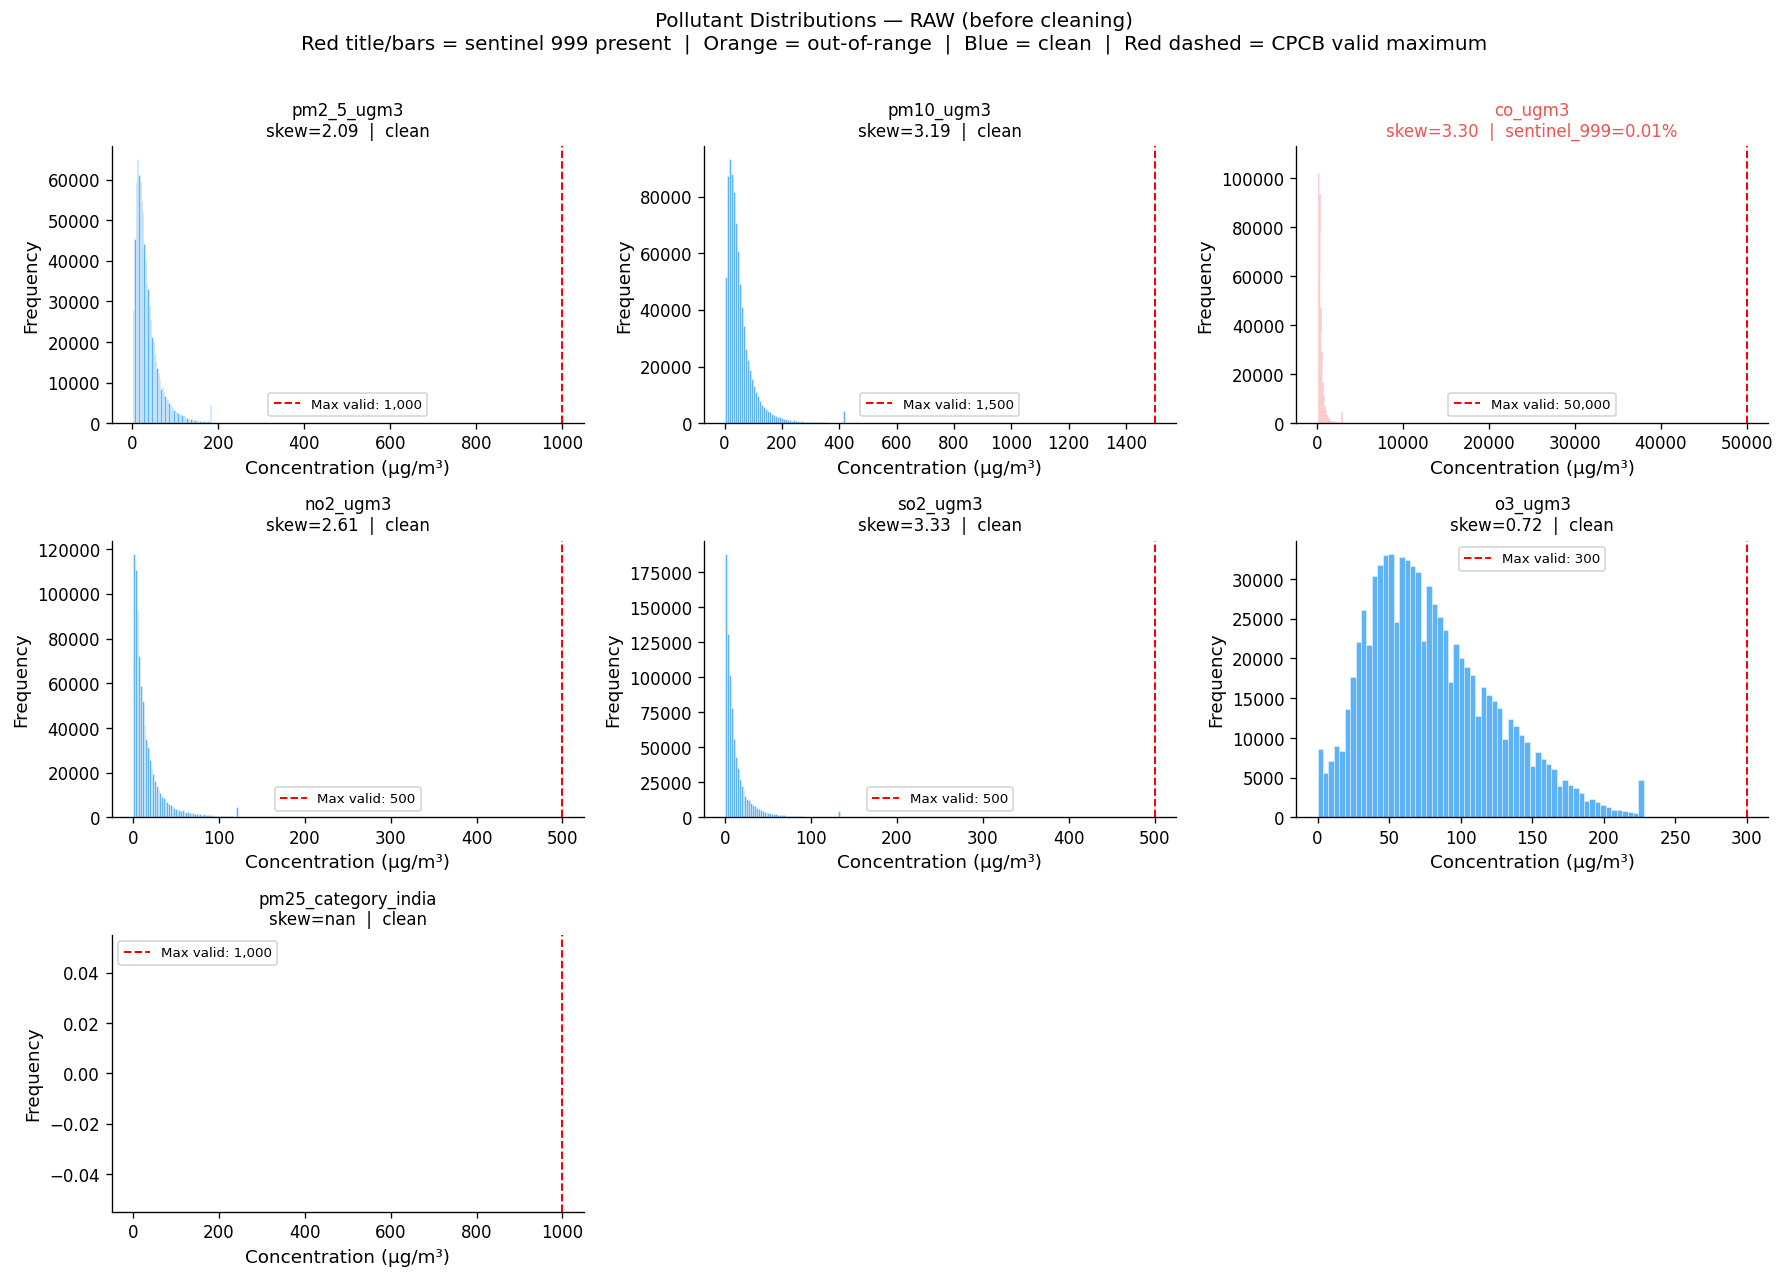


SKEWNESS SUMMARY (relevant for log-transform decision in feature engineering):
  Column                 Skewness   Recommendation
  ------------------------------------------------------------
  pm2_5_ugm3                2.088   consider log-transform
  pm10_ugm3                 3.188   consider log-transform
  co_ugm3                   3.300   consider log-transform
  no2_ugm3                  2.611   consider log-transform
  so2_ugm3                  3.328   consider log-transform
  o3_ugm3                   0.716   symmetric enough
  pm25_category_india         nan   symmetric enough


In [7]:
# ── Unit-aware valid range tables ─────────────────────────────────────────────
VALID_RANGES_UGM3 = {
    'pm2'  : (0, 1000),
    'pm10' : (0, 1500),
    'no2'  : (0, 500),
    'so2'  : (0, 500),
    'co'   : (0, 50000),   # 50 mg/m³ × 1000 = 50,000 µg/m³
    'ozone': (0, 300),
    'o3'   : (0, 300),
    'nh3'  : (0, 400),
    'nox'  : (0, 1000),
}

VALID_RANGES_MGM3 = {
    'pm2'  : (0, 1000),
    'pm10' : (0, 1500),
    'no2'  : (0, 500),
    'so2'  : (0, 500),
    'co'   : (0, 50),      # mg/m³ — only used if column name has no ugm3
    'ozone': (0, 300),
    'o3'   : (0, 300),
    'nh3'  : (0, 400),
    'nox'  : (0, 1000),
}

# ── Check each pollutant column ───────────────────────────────────────────────
print(f'{"="*70}')
print(f'  PHYSICAL RANGE VALIDATION — RAW DATA (observation only, no changes)')
print(f'{"="*70}')

range_results = []

for col in pollutant_cols:
    cl     = col.lower()
    ranges = VALID_RANGES_UGM3 if ('ugm3' in cl or 'ug_m3' in cl or 'ug/m3' in cl) \
             else VALID_RANGES_MGM3

    matched_range = None
    for kw, (lo, hi) in ranges.items():
        if kw in cl:
            matched_range = (lo, hi)
            break

    vals = pd.to_numeric(df[col], errors='coerce')

    if matched_range:
        lo, hi   = matched_range
        below    = (vals < lo).sum()
        above    = (vals > hi).sum()
        out_total = below + above
        in_range  = vals.notna().sum() - out_total
        flag      = '  <- OUT OF RANGE VALUES FOUND' if out_total > 0 else '  OK'

        print(f'\n  {col}')
        print(f'    Valid range    : [{lo:,} — {hi:,}] µg/m³')
        print(f'    Below minimum  : {below:,}')
        print(f'    Above maximum  : {above:,}')
        print(f'    Total flagged  : {out_total:,}{flag}')
        print(f'    In range       : {in_range:,}  ({in_range/len(df)*100:.2f}%)')

        range_results.append({
            'column'       : col,
            'valid_min'    : lo,
            'valid_max'    : hi,
            'below_min'    : below,
            'above_max'    : above,
            'out_of_range' : out_total,
            'pct_flagged'  : round(out_total / len(df) * 100, 4)
        })
    else:
        print(f'\n  {col}  — no range rule matched, skipped')

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"="*70}')
print('  RANGE VALIDATION SUMMARY')
print(f'{"="*70}')
range_df = pd.DataFrame(range_results)
display(range_df)

total_flagged = range_df['out_of_range'].sum()
print(f'\n  Total out-of-range values across all pollutants : {total_flagged:,}')
if total_flagged == 0:
    print('  All pollutant readings are within physical limits.')
    print('  The only corrupt values are the sentinel 999s identified above.')
else:
    print('  WARNING: out-of-range values found — will be nulled in cleaning step.')

# ── Visualisation — distribution of each pollutant with valid range marker ────
n      = len(pollutant_cols)
ncols  = 3
nrows  = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    vals    = pd.to_numeric(df[col], errors='coerce').dropna()

    # Get valid range for this column
    cl     = col.lower()
    ranges = VALID_RANGES_UGM3 if 'ugm3' in cl else VALID_RANGES_MGM3
    lo, hi = next(
        ((lo, hi) for kw, (lo, hi) in ranges.items() if kw in cl),
        (0, vals.max())
    )

    # Flag out-of-range and sentinel separately
    sentinel_pct  = (vals == 999).mean() * 100
    out_range_pct = ((vals < lo) | (vals > hi)).mean() * 100
    skewness      = vals[vals <= hi * 1.1].skew()

    # Color: red if sentinel present, orange if out-of-range, blue if clean
    if sentinel_pct > 0:
        color      = '#EF5350'
        title_color = '#EF5350'
        status     = f'sentinel_999={sentinel_pct:.2f}%'
    elif out_range_pct > 0:
        color      = '#FF9800'
        title_color = '#FF9800'
        status     = f'out_of_range={out_range_pct:.2f}%'
    else:
        color      = '#42A5F5'
        title_color = 'black'
        status     = 'clean'

    # Plot — cap x-axis at valid max for readability
    vals_vis = vals[vals <= hi]
    axes[i].hist(vals_vis, bins=60, color=color,
                 edgecolor='white', linewidth=0.3, alpha=0.85)

    # Valid max line
    axes[i].axvline(hi, color='red', linestyle='--',
                    linewidth=1.2, label=f'Max valid: {hi:,}')

    axes[i].set_title(
        f'{col}\nskew={skewness:.2f}  |  {status}',
        fontsize=10, color=title_color
    )
    axes[i].set_xlabel('Concentration (µg/m³)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Pollutant Distributions — RAW (before cleaning)\n'
    'Red title/bars = sentinel 999 present  |  '
    'Orange = out-of-range  |  '
    'Blue = clean  |  '
    'Red dashed = CPCB valid maximum',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

# ── Skewness summary ──────────────────────────────────────────────────────────
print('\nSKEWNESS SUMMARY (relevant for log-transform decision in feature engineering):')
print(f'  {"Column":<20} {"Skewness":>10}   {"Recommendation"}')
print(f'  {"-"*60}')
for col in pollutant_cols:
    vals     = pd.to_numeric(df[col], errors='coerce').dropna()
    cl       = col.lower()
    ranges   = VALID_RANGES_UGM3 if 'ugm3' in cl else VALID_RANGES_MGM3
    _, hi    = next(((lo, hi) for kw, (lo, hi) in ranges.items() if kw in cl), (0, 9999))
    skew_val = vals[vals <= hi].skew()
    rec      = 'consider log-transform' if abs(skew_val) > 1 else 'symmetric enough'
    print(f'  {col:<20} {skew_val:>10.3f}   {rec}')

### Section 4 — Geographic and Temporal Coverage

Two questions need answering before we trust the dataset for modelling:

**Geographic:** Are all 29 cities represented equally? If Delhi has 3x more
rows than Aizawl, any model trained on this data will be biased toward
predicting Delhi-like pollution patterns. Unequal city representation requires
stratified sampling during train/test split.

**Temporal:** Does the data cover time consistently? A gap of several months
in a specific year means the model never sees that seasonal pattern for that
period. Uneven monthly distribution affects the validity of time-based features
like `month` and `season`.

The imbalance ratio is calculated as:
```
imbalance_ratio = max_city_rows / this_city_rows
```

A ratio of 1.0 means perfect balance. A ratio above 2.0 means this city has
less than half the data of the most-represented city — flagged in red.

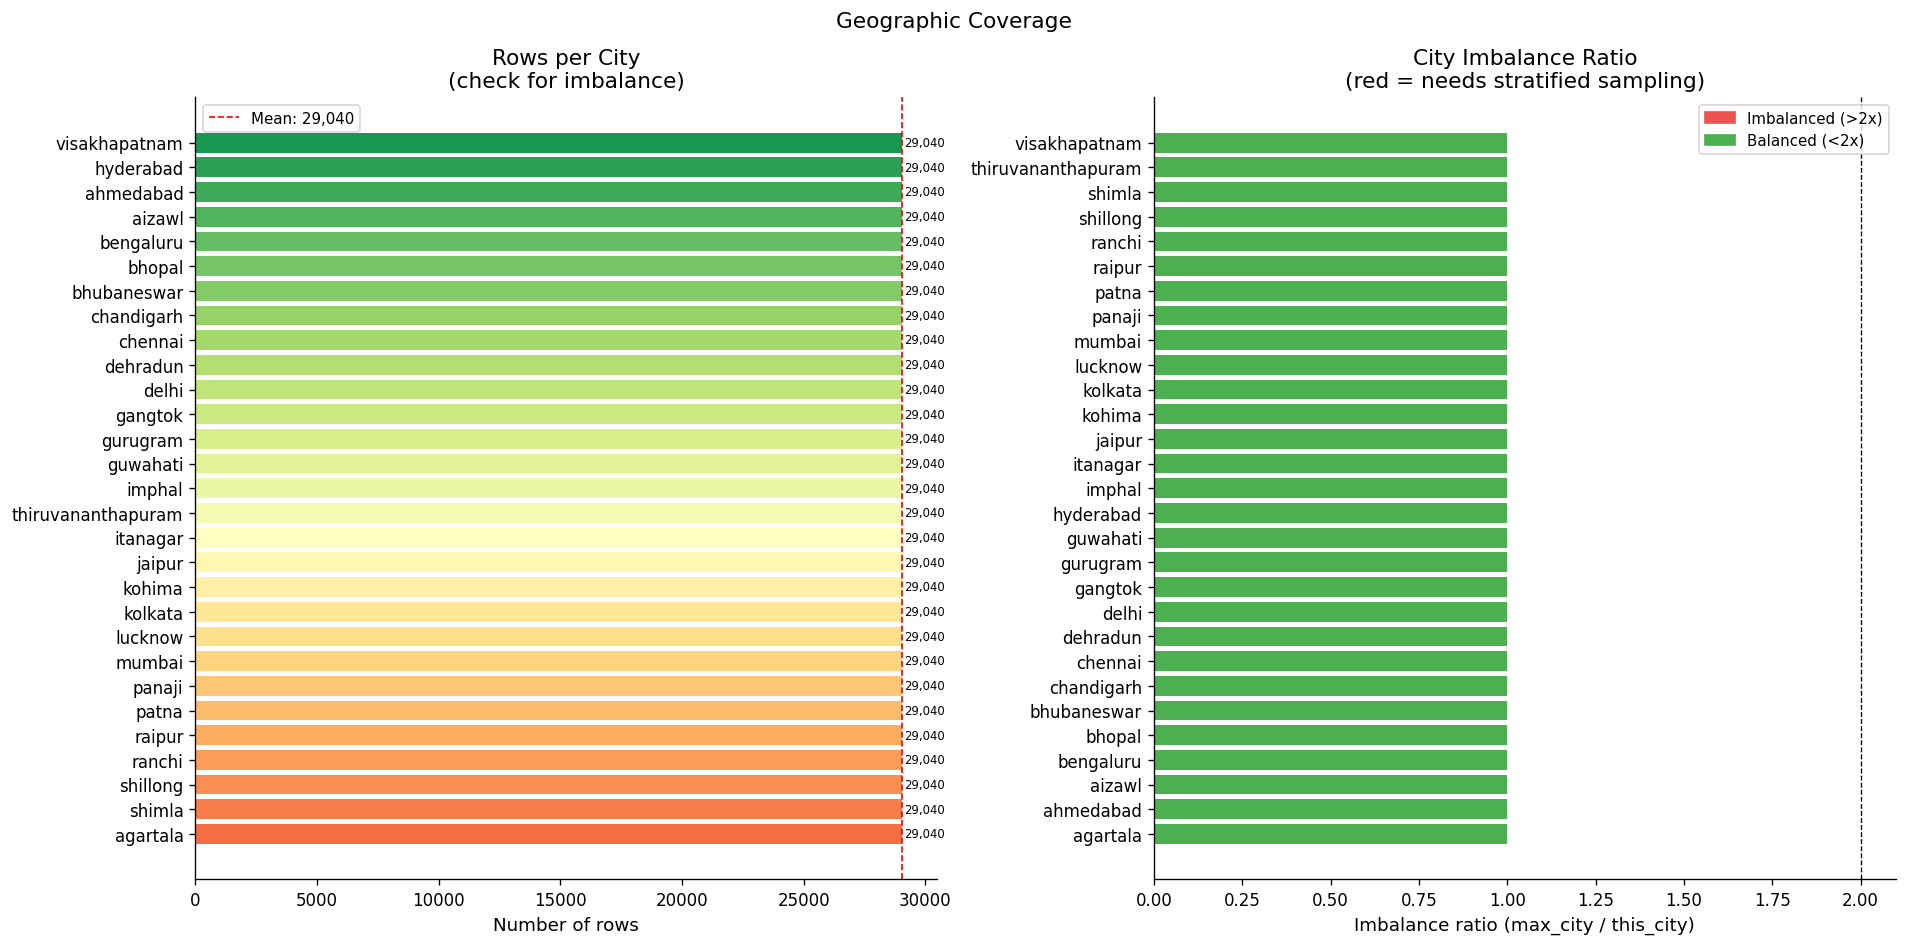

Total cities  : 29
Max rows      : 29,040  (agartala)
Min rows      : 29,040  (agartala)
Imbalance     : 1.00x
  All cities balanced — standard train/test split is sufficient.


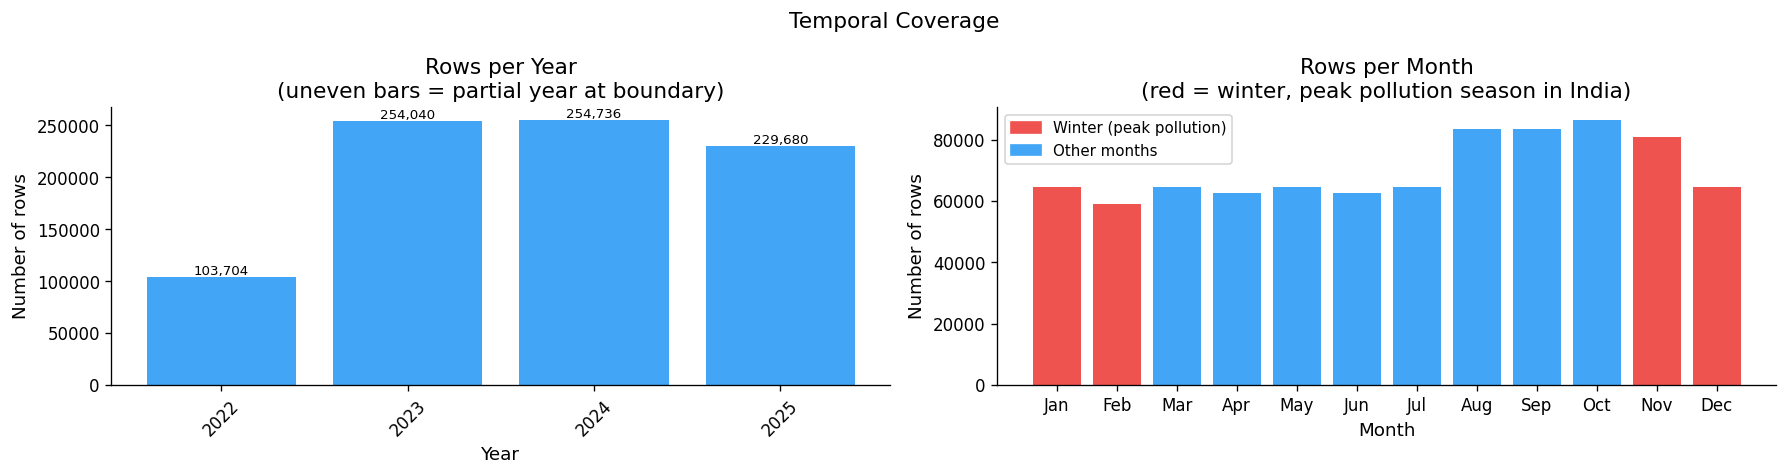

Date range : 2022-08-05  to  2025-11-26
Years covered : [2022, 2023, 2024, 2025]
All 12 months present : True


In [8]:
# ── Geographic coverage ───────────────────────────────────────────────────────
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df['_year']  = df[date_col].dt.year
df['_month'] = df[date_col].dt.month

city_counts = df[city_col].value_counts().sort_values(ascending=True)
imbalance   = (city_counts.max() / city_counts).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: rows per city
colors_city = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(city_counts)))
bars = axes[0].barh(city_counts.index, city_counts.values, color=colors_city)
axes[0].axvline(city_counts.mean(), color='red', linestyle='--',
                linewidth=1, label=f'Mean: {city_counts.mean():,.0f}')
axes[0].set_xlabel('Number of rows')
axes[0].set_title('Rows per City\n(check for imbalance)')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, city_counts.values):
    axes[0].text(val + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=7)

# Right: imbalance ratio
colors_imb = ['#EF5350' if v > 2 else '#4CAF50' for v in imbalance.values]
axes[1].barh(imbalance.index, imbalance.values, color=colors_imb)
axes[1].axvline(2, color='black', linestyle='--', linewidth=0.8, label='2x threshold')
axes[1].set_xlabel('Imbalance ratio (max_city / this_city)')
axes[1].set_title('City Imbalance Ratio\n(red = needs stratified sampling)')
red_p   = mpatches.Patch(color='#EF5350', label='Imbalanced (>2x)')
green_p = mpatches.Patch(color='#4CAF50', label='Balanced (<2x)')
axes[1].legend(handles=[red_p, green_p], fontsize=9)

plt.suptitle('Geographic Coverage', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Total cities  : {len(city_counts)}')
print(f'Max rows      : {city_counts.max():,}  ({city_counts.idxmax()})')
print(f'Min rows      : {city_counts.min():,}  ({city_counts.idxmin()})')
print(f'Imbalance     : {city_counts.max()/city_counts.min():.2f}x')
if city_counts.max()/city_counts.min() <= 2:
    print('  All cities balanced — standard train/test split is sufficient.')
else:
    print('  Imbalance detected — use stratify=city in train_test_split.')

# ── Temporal coverage ─────────────────────────────────────────────────────────
year_counts  = df['_year'].value_counts().sort_index()
month_counts = df['_month'].value_counts().sort_index()
month_names  = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].bar(year_counts.index.astype(str), year_counts.values, color='#42A5F5')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of rows')
axes[0].set_title('Rows per Year\n(uneven bars = partial year at boundary)')
axes[0].tick_params(axis='x', rotation=45)
for i, (yr, val) in enumerate(year_counts.items()):
    axes[0].text(i, val + year_counts.max()*0.01,
                 f'{val:,}', ha='center', fontsize=8)

m_idx    = month_counts.index.tolist()
m_names  = [month_names[m-1] for m in m_idx]
m_colors = ['#EF5350' if m in [11, 12, 1, 2] else '#42A5F5' for m in m_idx]
axes[1].bar(m_names, month_counts.values, color=m_colors)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of rows')
axes[1].set_title('Rows per Month\n(red = winter, peak pollution season in India)')
red_p  = mpatches.Patch(color='#EF5350', label='Winter (peak pollution)')
blue_p = mpatches.Patch(color='#42A5F5', label='Other months')
axes[1].legend(handles=[red_p, blue_p], fontsize=9)

plt.suptitle('Temporal Coverage', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Date range : {df[date_col].min().date()}  to  {df[date_col].max().date()}')
print(f'Years covered : {sorted(year_counts.index.tolist())}')
print(f'All 12 months present : {len(month_counts) == 12}')

df.drop(columns=['_year', '_month'], inplace=True)

### Section 5 — Pollutant Correlation Matrix

Before selecting features for regression and classification, we need to
understand how the 6 pollutants relate to each other. High correlation between
two features — called multicollinearity — causes a specific problem in linear
regression: the model cannot reliably assign individual coefficients because
it cannot distinguish which of the two correlated features is actually driving
the prediction.

The Pearson correlation coefficient ranges from -1 to +1:

| Range | Interpretation |
|---|---|
| 0.9 – 1.0 | Very high — strong multicollinearity risk, consider dropping one |
| 0.7 – 0.9 | High — monitor with VIF in feature selection |
| 0.4 – 0.7 | Moderate — acceptable |
| 0.0 – 0.4 | Weak — no concern |
| Negative   | Inverse relationship — one rises as the other falls |

O3 (ozone) is expected to show negative correlation with traffic pollutants
like NO2 and CO. This is a real atmospheric chemistry effect — NO2 reacts with
and destroys ground-level ozone in a process called ozone titration. Seeing
this in the data is a signal that the dataset is physically valid.

> **Note:** This correlation matrix is computed on raw data with sentinel 999
> still present in `co_ugm3`. The 124 corrupt values will slightly distort CO's
> correlations. The matrix will be recomputed after cleaning for the true picture.

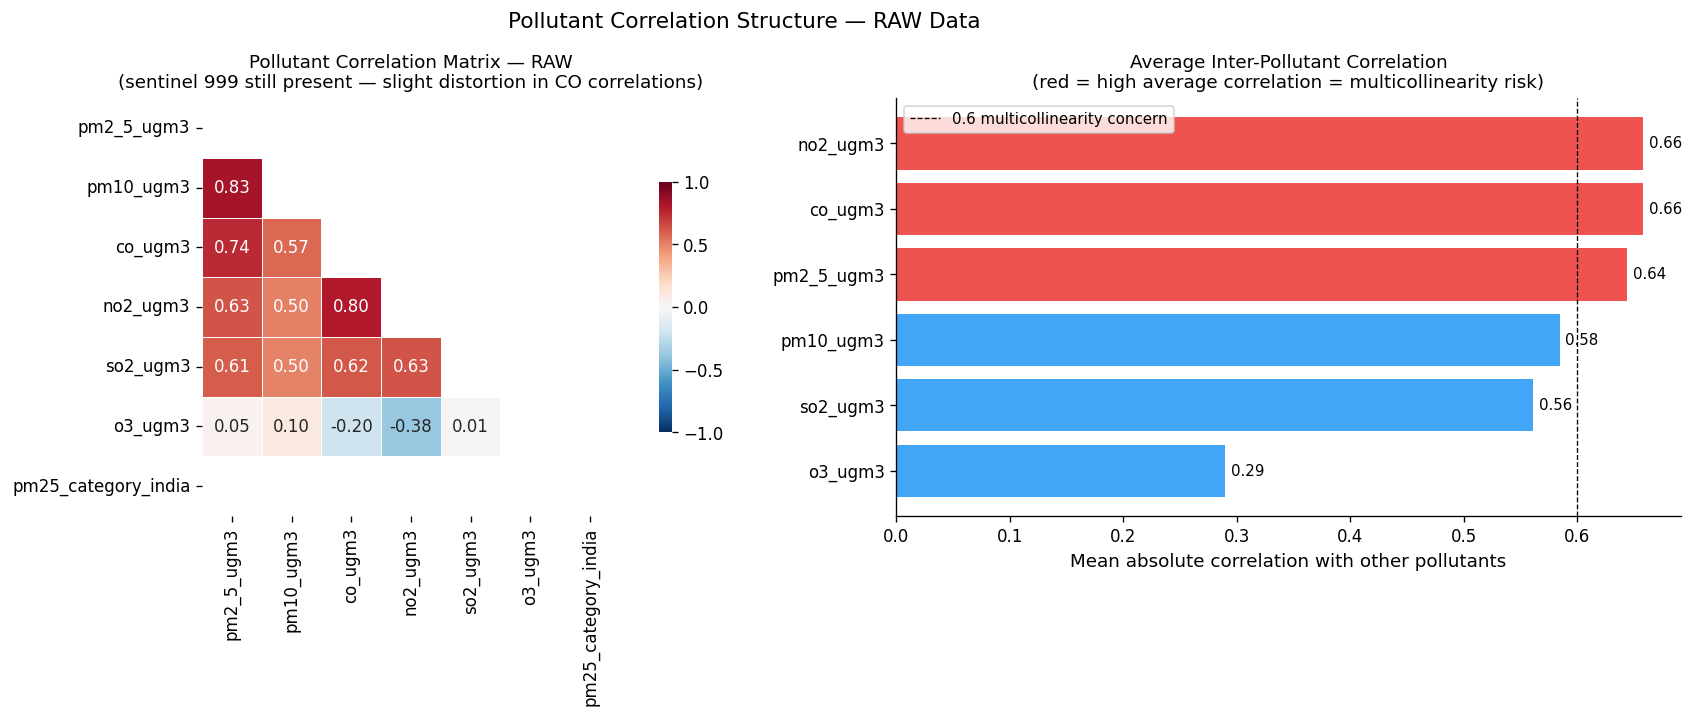

High correlation pairs (|r| > 0.7):
  pm2_5_ugm3           <-> pm10_ugm3             r = 0.834  (moderate risk)
  pm2_5_ugm3           <-> co_ugm3               r = 0.744  (moderate risk)
  co_ugm3              <-> no2_ugm3              r = 0.802  (moderate risk)

O3 correlations (expect negative with traffic pollutants):
  o3_ugm3 <-> pm2_5_ugm3            r = 0.047  (positive)
  o3_ugm3 <-> pm10_ugm3             r = 0.101  (positive)
  o3_ugm3 <-> co_ugm3               r = -0.204  (negative (expected))
  o3_ugm3 <-> no2_ugm3              r = -0.379  (negative (expected))
  o3_ugm3 <-> so2_ugm3              r = 0.009  (positive)
  o3_ugm3 <-> pm25_category_india   r = nan  (positive)


In [9]:
# ── Correlation matrix on raw pollutant data ──────────────────────────────────
corr_df  = df[pollutant_cols].apply(pd.to_numeric, errors='coerce')
corr_mat = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full heatmap
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=axes[0],
    cbar_kws={'shrink': 0.6}, annot_kws={'size': 10}
)
axes[0].set_title(
    'Pollutant Correlation Matrix — RAW\n'
    '(sentinel 999 still present — slight distortion in CO correlations)',
    fontsize=11
)

# Right: bar chart of each pollutant's avg absolute correlation with others
avg_corr = corr_mat.abs().mean().sort_values(ascending=True)
bar_colors = ['#EF5350' if v > 0.6 else '#42A5F5' for v in avg_corr.values]
bars = axes[1].barh(avg_corr.index, avg_corr.values, color=bar_colors)
axes[1].axvline(0.6, color='black', linestyle='--',
                linewidth=0.8, label='0.6 multicollinearity concern')
for bar, val in zip(bars, avg_corr.values):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
axes[1].set_xlabel('Mean absolute correlation with other pollutants')
axes[1].set_title(
    'Average Inter-Pollutant Correlation\n'
    '(red = high average correlation = multicollinearity risk)',
    fontsize=11
)
axes[1].legend(fontsize=9)

plt.suptitle('Pollutant Correlation Structure — RAW Data', fontsize=13)
plt.tight_layout()
plt.show()

# ── Flag high pairs ───────────────────────────────────────────────────────────
print('High correlation pairs (|r| > 0.7):')
found = False
for i, c1 in enumerate(pollutant_cols):
    for c2 in pollutant_cols[i+1:]:
        r = corr_mat.loc[c1, c2]
        if abs(r) > 0.7:
            risk = 'HIGH risk' if abs(r) > 0.85 else 'moderate risk'
            print(f'  {c1:<20} <-> {c2:<20}  r = {r:.3f}  ({risk})')
            found = True
if not found:
    print('  None — no multicollinearity concerns at 0.7 threshold.')

print('\nO3 correlations (expect negative with traffic pollutants):')
for col in pollutant_cols:
    if col != 'o3_ugm3' and 'o3' in 'o3_ugm3':
        pass
o3_col = next((c for c in pollutant_cols if 'o3' in c.lower()), None)
if o3_col:
    for col in pollutant_cols:
        if col != o3_col:
            r = corr_mat.loc[o3_col, col]
            direction = 'negative (expected)' if r < 0 else 'positive'
            print(f'  {o3_col} <-> {col:<20}  r = {r:.3f}  ({direction})')

### Section 6 — Target Variable Analysis

The dataset has two potential target variables depending on the ML task:

**Regression target — AQI numeric (0–500)**
A continuous number computed from the 6 pollutant sub-indices using the CPCB
formula. This file has no pre-computed AQI column — it must be derived in the
cleaning step using the official breakpoint table.

**Classification target — AQI_category (6 classes)**
A text label derived from the numeric AQI using CPCB thresholds. This column
exists in the file but may use non-standard category names — the US EPA naming
convention (Unhealthy, Very Unhealthy) instead of CPCB naming (Poor, Very Poor).
This requires standardisation before encoding.

### Class Imbalance

For classification, the distribution of rows across the 6 categories directly
affects model behaviour. A model trained on imbalanced classes will develop a
bias toward the majority class — if 70% of rows are Moderate, predicting
Moderate for every input achieves 70% accuracy without learning anything.

The imbalance ratio is:
```
imbalance_ratio = majority_class_count / minority_class_count
```

| Ratio | Strategy |
|---|---|
| < 3x | No action needed |
| 3x – 10x | `class_weight='balanced'` in model constructor |
| > 10x | SMOTE oversampling on training set only |

AQI numeric col  : None
AQI category col : aqi_category

Class distribution (standardised to CPCB naming):
  Good            136,476.0  ( 16.2%)  ########
  Moderate        385,833.0  ( 45.8%)  ######################
  Poor            175,125.0  ( 20.8%)  ##########
  Very Poor       144,726.0  ( 17.2%)  ########

Imbalance ratio : 2.8x
Strategy        : Balanced enough — no action needed


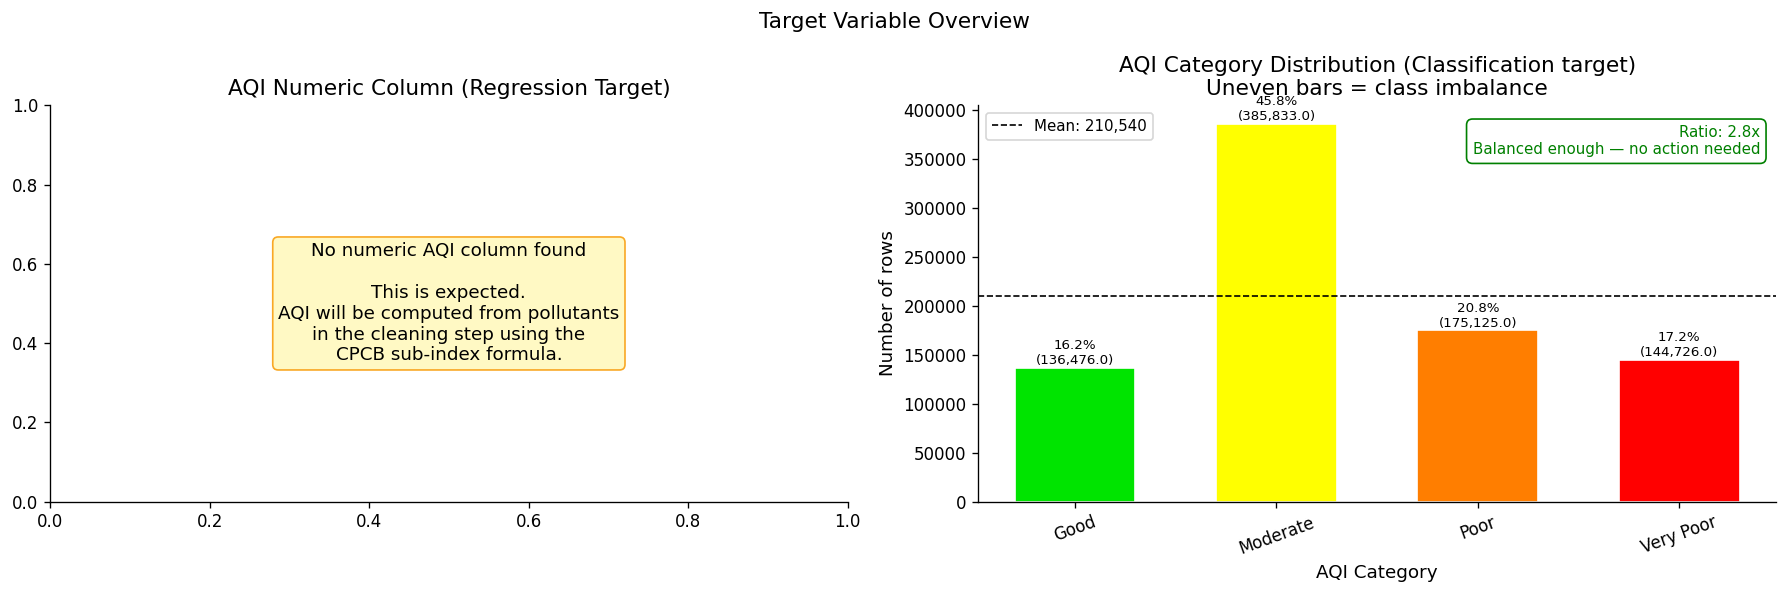

In [10]:
# ── Check for numeric AQI column ─────────────────────────────────────────────
print(f'AQI numeric col  : {aqi_col}')
print(f'AQI category col : {cat_col}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: numeric AQI ────────────────────────────────────────────────────────
if aqi_col:
    aqi_vals  = pd.to_numeric(df[aqi_col], errors='coerce')
    aqi_clean = aqi_vals[(aqi_vals >= 0) & (aqi_vals <= 500)]

    band_edges  = [0,  50, 100, 200, 300, 400, 500]
    band_colors = ['#00E400','#92D050','#FFFF00','#FF7E00','#FF0000','#99004C']
    band_labels = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']

    axes[0].hist(aqi_clean, bins=80, color='#90CAF9',
                 edgecolor='white', linewidth=0.2)
    for lo, hi, cb in zip(band_edges[:-1], band_edges[1:], band_colors):
        axes[0].axvspan(lo, hi, alpha=0.12, color=cb)
    for edge, label, cb in zip(band_edges[1:], band_labels, band_colors):
        axes[0].axvline(edge, color=cb, linewidth=0.8, linestyle='--')
    axes[0].set_xlabel('AQI Value')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(
        f'AQI Distribution (Regression target)\n'
        f'mean={aqi_clean.mean():.0f}  |  median={aqi_clean.median():.0f}'
    )
else:
    axes[0].text(
        0.5, 0.5,
        'No numeric AQI column found\n\n'
        'This is expected.\n'
        'AQI will be computed from pollutants\n'
        'in the cleaning step using the\n'
        'CPCB sub-index formula.',
        ha='center', va='center',
        transform=axes[0].transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='#FFF9C4', edgecolor='#F9A825')
    )
    axes[0].set_title('AQI Numeric Column (Regression Target)')

# ── Right: category distribution ─────────────────────────────────────────────
if cat_col:
    # Standardise category names to CPCB convention
    name_map = {
        'good'                      : 'Good',
        'satisfactory'              : 'Satisfactory',
        'moderate'                  : 'Moderate',
        'poor'                      : 'Poor',
        'very poor'                 : 'Very Poor',
        'severe'                    : 'Severe',
        'unhealthy for sensitive'   : 'Poor',
        'unhealthy'                 : 'Very Poor',
        'very unhealthy'            : 'Severe',
        'hazardous'                 : 'Severe',
    }

    cat_vals = (
        df[cat_col]
        .astype(str).str.strip().str.lower()
        .map(lambda x: next(
            (v for k, v in name_map.items() if k in x), x.title()
        ))
    )

    cat_order  = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
    cat_colors = ['#00E400','#92D050','#FFFF00','#FF7E00','#FF0000','#99004C']

    counts = cat_vals.value_counts().reindex(cat_order).dropna()
    pcts   = (counts / counts.sum() * 100).round(1)
    clrs   = [cat_colors[cat_order.index(c)] for c in counts.index if c in cat_order]

    bars = axes[1].bar(counts.index, counts.values,
                       color=clrs, edgecolor='white', width=0.6)
    axes[1].axhline(counts.mean(), color='black', linestyle='--',
                    linewidth=1, label=f'Mean: {counts.mean():,.0f}')
    for bar, pct, val in zip(bars, pcts.values, counts.values):
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + counts.max()*0.01,
            f'{pct:.1f}%\n({val:,})',
            ha='center', fontsize=8
        )
    axes[1].set_xlabel('AQI Category')
    axes[1].set_ylabel('Number of rows')
    axes[1].set_title(
        'AQI Category Distribution (Classification target)\n'
        'Uneven bars = class imbalance'
    )
    axes[1].legend(fontsize=9)
    axes[1].tick_params(axis='x', rotation=20)

    # Imbalance check
    imb_ratio = counts.max() / counts.min()
    if   imb_ratio > 10: strategy = 'SMOTE required (severe imbalance)'
    elif imb_ratio > 3:  strategy = 'class_weight="balanced" recommended'
    else:                strategy = 'Balanced enough — no action needed'

    warn_color = 'red' if imb_ratio > 10 else 'orange' if imb_ratio > 3 else 'green'
    axes[1].text(
        0.98, 0.95,
        f'Ratio: {imb_ratio:.1f}x\n{strategy}',
        ha='right', va='top',
        transform=axes[1].transAxes, fontsize=9,
        color=warn_color,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=warn_color)
    )

    print('\nClass distribution (standardised to CPCB naming):')
    for cat, cnt, pct in zip(counts.index, counts.values, pcts.values):
        bar_str = '#' * int(pct / 2)
        print(f'  {cat:<15} {cnt:>8,}  ({pct:>5.1f}%)  {bar_str}')
    print(f'\nImbalance ratio : {imb_ratio:.1f}x')
    print(f'Strategy        : {strategy}')

plt.suptitle('Target Variable Overview', fontsize=13)
plt.tight_layout()
plt.show()

### Section 7 — EDA Summary and Cleaning Plan

Every section above was observation only. We now have a complete diagnosis
of the raw dataset. This section consolidates every finding into a single
reference table and defines exactly what the cleaning step will do and why.

Nothing has been modified yet. The dataframe `df` still contains the original
raw values including all sentinel 999s and any detected issues above.

In [11]:
# ── Recompute all counts for summary ─────────────────────────────────────────
sentinel_total = sum(
    (pd.to_numeric(df[c], errors='coerce') == 999).sum()
    for c in df.select_dtypes(include=[np.number]).columns
)
null_total   = df.isnull().sum().sum()
city_count   = df[city_col].nunique()
imb_ratio_city = city_counts.max() / city_counts.min()

total_out_of_range = sum(
    r['out_of_range'] for r in range_results
)

print('=' * 65)
print('  EDA COMPLETE — FULL FINDINGS SUMMARY')
print('=' * 65)
print(f'  Rows                      : {len(df):,}')
print(f'  Columns                   : {len(df.columns)}')
print(f'  Cities                    : {city_count}')
print(f'  Date range                : {df[date_col].min().date()} to {df[date_col].max().date()}')
print(f'  Standard NaN values       : {null_total:,}')
print(f'  Sentinel 999 values       : {sentinel_total:,}  <- treat as missing')
print(f'  Out-of-range readings     : {total_out_of_range:,}')
print(f'  City imbalance ratio      : {imb_ratio_city:.2f}x')
print(f'  Pollutant cols detected   : {pollutant_cols}')
print(f'  AQI numeric col           : {aqi_col}  (None = must compute)')
print(f'  AQI category col          : {cat_col}')

print(f'\n  ISSUES FOUND:')
issues = []
if sentinel_total > 0:
    issues.append(f'  [1] Sentinel 999 values present ({sentinel_total:,}) — must be nulled')
if total_out_of_range > 0:
    issues.append(f'  [2] Out-of-range readings ({total_out_of_range:,}) — must be nulled')
if null_total > 0:
    issues.append(f'  [3] Standard NaN values ({null_total:,}) — forward fill or drop')
if aqi_col is None:
    issues.append(f'  [4] No numeric AQI column — must compute from pollutants')
if not issues:
    issues.append('  None critical — only sentinel values require fixing')
for issue in issues:
    print(issue)

print(f'\n  CLEANING PLAN (next section):')
print(f'  Step 1 — Replace sentinel 999 → NaN across all numeric columns')
print(f'  Step 2 — Apply physical range validation per pollutant')
print(f'  Step 3 — Forward fill short sensor gaps (limit=3 hours) per city')
print(f'  Step 4 — Drop rows where all pollutants are still NaN')
print(f'  Step 5 — Remove duplicate (city, datetime) rows')
print(f'  Step 6 — Parse datetime and extract time features')
print(f'  Step 7 — Standardise AQI_category labels to CPCB convention')
print(f'  Step 8 — Compute numeric AQI from pollutants using CPCB formula')
print(f'  Step 9 — Save master cleaned file to data/cleaned/05_shared/')
print('=' * 65)

  EDA COMPLETE — FULL FINDINGS SUMMARY
  Rows                      : 842,160
  Columns                   : 31
  Cities                    : 29
  Date range                : 2022-08-05 to 2025-11-26
  Standard NaN values       : 2
  Sentinel 999 values       : 1,477  <- treat as missing
  Out-of-range readings     : 0
  City imbalance ratio      : 1.00x
  Pollutant cols detected   : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'pm25_category_india']
  AQI numeric col           : None  (None = must compute)
  AQI category col          : aqi_category

  ISSUES FOUND:
  [1] Sentinel 999 values present (1,477) — must be nulled
  [3] Standard NaN values (2) — forward fill or drop
  [4] No numeric AQI column — must compute from pollutants

  CLEANING PLAN (next section):
  Step 1 — Replace sentinel 999 → NaN across all numeric columns
  Step 2 — Apply physical range validation per pollutant
  Step 3 — Forward fill short sensor gaps (limit=3 hours) per city
  Step 

## Data Cleaning Pipeline

The EDA section identified every problem in the raw dataset. This section fixes
them in a specific order. The order matters — forward filling before sentinel
removal would propagate corrupt 999 values into neighbouring rows. Range
validation before sentinel removal would miss the 999s in CO since 999 falls
within the valid CO range of (0, 50000).

Every operation follows the same pattern:
- Row count logged before and after
- Values changed are counted and reported
- A before/after comparison is shown where relevant

The cleaning log accumulates across all operations and is printed as a
waterfall summary at the end.

### Operation Order and Rationale

| Step | Operation | Why This Order |
|---|---|---|
| 1 | Replace sentinel 999 → NaN | Must come first — 999 is not caught by range checks |
| 2 | Physical range validation | After sentinel removal — now only real out-of-range values remain |
| 3 | Forward fill gaps ≤ 3 hours | After nulling — fills short dropouts left by steps 1 and 2 |
| 4 | Drop all-null pollutant rows | After fill — rows still all-null are extended outages, unrecoverable |
| 5 | Deduplication | After row-level fixes — removes overlap artifacts |
| 6 | Datetime parsing + time features | Structural fix — needed for all downstream temporal features |
| 7 | Standardise AQI category labels | Final fix — prepares classification target |

In [12]:
# ── Cleaning infrastructure ───────────────────────────────────────────────────
cleaning_log = []

def log_step(step_name, rows_before, rows_after, notes=''):
    removed = rows_before - rows_after
    cleaning_log.append({
        'step'        : step_name,
        'rows_before' : rows_before,
        'rows_after'  : rows_after,
        'rows_removed': removed,
        'pct_removed' : round(removed / rows_before * 100, 3) if rows_before else 0,
        'notes'       : notes
    })
    flag = '  <- ROWS DROPPED' if removed > 0 else ''
    print(
        f'  [{step_name}]  '
        f'{rows_before:,} -> {rows_after:,}  '
        f'({removed:,} removed, {removed/rows_before*100:.3f}%)  '
        f'{notes}{flag}'
    )

print('Cleaning log initialised.')
print('Starting row count:', f'{len(df):,}')

Cleaning log initialised.
Starting row count: 842,160


### Operation 1 — Replace Sentinel 999 → NaN

CPCB CAAQMS stations record exactly `999` when a sensor goes offline, loses
power, or produces a reading outside its measurement range. This is a domain
convention, not a standard missing value marker.

Real-world evidence that 999 is always a sentinel and never a real reading:
- PM2.5 peaked at approximately 900 µg/m³ during post-Diwali Delhi 2021 —
  the worst recorded pollution event in India
- A reading of exactly 999 across any pollutant is therefore physically
  impossible as a genuine measurement

If left in, the model learns that PM2.5 = 999 maps to some AQI value. This
corrupts every coefficient the regression model estimates and every decision
boundary the classification model draws.

This operation replaces all 999 values across every numeric column with `NaN`
so they are treated as missing and handled by the forward fill in Operation 3.


In [13]:
rows_before  = len(df)
numeric_cols = df.select_dtypes(include=[np.number]).columns
replacements = 0

print('Sentinel 999 counts BEFORE replacement:')
for col in pollutant_cols:
    count = (df[col] == 999).sum()
    if count > 0:
        print(f'  {col:<35} {count:>8,}')

for col in numeric_cols:
    mask          = df[col] == 999
    replacements += mask.sum()
    df.loc[mask, col] = np.nan

rows_after = len(df)
log_step(
    'Replace 999->NaN', rows_before, rows_after,
    f'{replacements:,} values replaced across {len(numeric_cols)} numeric columns'
)

print('\nSentinel 999 counts AFTER replacement:')
for col in pollutant_cols:
    count = (df[col] == 999).sum()
    print(f'  {col:<35} {count:>8,}  {"OK" if count == 0 else "<- still present"}')

print('\nNaN counts in pollutant cols after sentinel replacement:')
for col in pollutant_cols:
    n   = df[col].isnull().sum()
    pct = n / len(df) * 100
    print(f'  {col:<35} {n:>8,}  ({pct:.3f}%)')

Sentinel 999 counts BEFORE replacement:
  co_ugm3                                  124
  [Replace 999->NaN]  842,160 -> 842,160  (0 removed, 0.000%)  1,477 values replaced across 18 numeric columns

Sentinel 999 counts AFTER replacement:
  pm2_5_ugm3                                 0  OK
  pm10_ugm3                                  0  OK
  co_ugm3                                    0  OK
  no2_ugm3                                   0  OK
  so2_ugm3                                   0  OK
  o3_ugm3                                    0  OK
  pm25_category_india                        0  OK

NaN counts in pollutant cols after sentinel replacement:
  pm2_5_ugm3                                 0  (0.000%)
  pm10_ugm3                                  0  (0.000%)
  co_ugm3                                  124  (0.015%)
  no2_ugm3                                   0  (0.000%)
  so2_ugm3                                   0  (0.000%)
  o3_ugm3                                    0  (0.000%)
  pm2

### Operation 2 — Physical Range Validation

After sentinel removal, any remaining out-of-range value is a genuine sensor
malfunction — the instrument returned a number, but that number is physically
impossible for that pollutant in any real-world condition.

The same unit-aware range table from the EDA section is applied here. The check
is automatic — if the column name contains `ugm3`, the µg/m³ limits are used.
If not, the mg/m³ limits are used. This prevents the CO unit bug where applying
the mg/m³ limit of 50 to the µg/m³ column would null every valid CO reading.

In [14]:
rows_before  = len(df)
total_nulled = 0

for col in pollutant_cols:
    cl     = col.lower()
    ranges = VALID_RANGES_UGM3 if ('ugm3' in cl or 'ug_m3' in cl) \
             else VALID_RANGES_MGM3

    matched_range = None
    for kw, (lo, hi) in ranges.items():
        if kw in cl:
            matched_range = (lo, hi)
            break

    if matched_range:
        lo, hi = matched_range
        vals   = pd.to_numeric(df[col], errors='coerce')
        mask   = (vals < lo) | (vals > hi)
        count  = mask.sum()
        if count > 0:
            df.loc[mask, col] = np.nan
            total_nulled += count
            print(f'  {col:<35} {count:>8,} values outside [{lo:,}, {hi:,}] -> NaN')
        else:
            print(f'  {col:<35} all values in range [{lo:,}, {hi:,}]  OK')
    else:
        print(f'  {col:<35} no range rule matched — skipped')

rows_after = len(df)
log_step(
    'Range validation', rows_before, rows_after,
    f'{total_nulled:,} out-of-range values nulled'
)

  pm2_5_ugm3                          all values in range [0, 1,000]  OK
  pm10_ugm3                           all values in range [0, 1,500]  OK
  co_ugm3                             all values in range [0, 50,000]  OK
  no2_ugm3                            all values in range [0, 500]  OK
  so2_ugm3                            all values in range [0, 500]  OK
  o3_ugm3                             all values in range [0, 300]  OK
  pm25_category_india                 all values in range [0, 1,000]  OK
  [Range validation]  842,160 -> 842,160  (0 removed, 0.000%)  0 out-of-range values nulled


### Operation 3 — Forward Fill Short Sensor Gaps

Operations 1 and 2 introduced NaN values where corrupt readings were. Some of
these are short gaps — a sensor went offline for 1 to 3 hours then came back.
Pollutant concentrations change slowly in real conditions, so carrying the last
known valid reading forward is a physically reasonable estimate for short gaps.

Two rules govern this fill:

- **Limit = 3:** Only fill gaps of 3 or fewer consecutive NaN rows. Larger
  gaps represent extended outages where the last known value is too stale to
  be a reliable estimate.
- **Per city:** Filling is applied within each city group independently.
  Delhi readings must never bleed into Mumbai. The `groupby(city_col)`
  ensures each city's time series is treated as a separate sequence.

The deprecated `fillna(method='ffill')` syntax is avoided — pandas ≥ 2.1
raises a `TypeError` for this form. We use `.ffill(limit=3)` directly.

In [15]:
rows_before      = len(df)
null_before_fill = df[pollutant_cols].isnull().sum().sum()

df = df.sort_values([city_col, date_col]).reset_index(drop=True)

df[pollutant_cols] = (
    df.groupby(city_col)[pollutant_cols]
    .transform(lambda x: x.ffill(limit=3))
)

null_after_fill = df[pollutant_cols].isnull().sum().sum()
filled_count    = null_before_fill - null_after_fill
rows_after      = len(df)

log_step(
    'Forward fill (limit=3)', rows_before, rows_after,
    f'{filled_count:,} NaN values filled, '
    f'{null_after_fill:,} NaN remain (gaps > 3 hrs)'
)

print('\nNaN counts per pollutant after forward fill:')
for col in pollutant_cols:
    n   = df[col].isnull().sum()
    pct = n / len(df) * 100
    print(f'  {col:<35} {n:>8,}  ({pct:.3f}%)')

  [Forward fill (limit=3)]  842,160 -> 842,160  (0 removed, 0.000%)  126 NaN values filled, 0 NaN remain (gaps > 3 hrs)

NaN counts per pollutant after forward fill:
  pm2_5_ugm3                                 0  (0.000%)
  pm10_ugm3                                  0  (0.000%)
  co_ugm3                                    0  (0.000%)
  no2_ugm3                                   0  (0.000%)
  so2_ugm3                                   0  (0.000%)
  o3_ugm3                                    0  (0.000%)
  pm25_category_india                        0  (0.000%)


### Operations 4–7 — Row Cleanup, Deduplication, Datetime, Category Labels

**Operation 4 — Drop all-null pollutant rows**
After forward fill, any row where every pollutant column is still NaN
represents an extended sensor outage that cannot be recovered. These rows
have no usable signal and must be dropped.

**Operation 5 — Deduplication**
CPCB data downloaded in overlapping date ranges produces duplicate rows.
The combination of city + datetime must be unique — one reading per station
per hour. Duplicates are identified on this pair and the first occurrence kept.

**Operation 6 — Datetime parsing and time feature extraction**
The datetime column is stored as a string. It must be parsed to a proper
`datetime64` type before any temporal operations. Time features — year, month,
day, hour, day_of_week, season — are added only if not already present.
These features capture the diurnal and seasonal pollution patterns that
are strong predictors of AQI.

**Operation 7 — Standardise AQI category labels**
The `aqi_category` column may use US EPA naming (Unhealthy, Very Unhealthy)
instead of CPCB naming (Poor, Very Poor). All variants are mapped to the
six official CPCB categories before encoding.

In [16]:
# ── Operation 4 — Drop all-null pollutant rows ────────────────────────────────
rows_before   = len(df)
all_null_mask = df[pollutant_cols].isnull().all(axis=1)
df            = df[~all_null_mask].reset_index(drop=True)
rows_after    = len(df)
log_step('Drop all-null rows', rows_before, rows_after,
         'Rows where every pollutant column was NaN')

# ── Operation 5 — Deduplication ───────────────────────────────────────────────
rows_before = len(df)
dedup_cols  = [c for c in [city_col, date_col] if c is not None]
df          = df.drop_duplicates(subset=dedup_cols, keep='first').reset_index(drop=True)
rows_after  = len(df)
log_step('Deduplication', rows_before, rows_after,
         f'Subset: {dedup_cols}')

# ── Operation 6 — Datetime parsing + time features ───────────────────────────
rows_before = len(df)
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

TIME_FEATURES = {
    'year'       : df[date_col].dt.year,
    'month'      : df[date_col].dt.month,
    'day'        : df[date_col].dt.day,
    'hour'       : df[date_col].dt.hour,
    'day_of_week': df[date_col].dt.dayofweek,
}
SEASON_MAP = {12:'Winter',1:'Winter',2:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Monsoon',10:'Monsoon',11:'Monsoon'}

for feat, series in TIME_FEATURES.items():
    if feat not in df.columns:
        df[feat] = series

if 'season' not in df.columns:
    df['season'] = df['month'].map(SEASON_MAP)

rows_after = len(df)
log_step('Datetime + time features', rows_before, rows_after,
         'Parsed datetime, added year/month/day/hour/day_of_week/season')

# ── Operation 7 — Standardise AQI category labels ────────────────────────────
rows_before = len(df)

CAT_MAP = {
    'good'                   : 'Good',
    'satisfactory'           : 'Satisfactory',
    'moderate'               : 'Moderate',
    'poor'                   : 'Poor',
    'very poor'              : 'Very Poor',
    'severe'                 : 'Severe',
    'unhealthy for sensitive': 'Poor',
    'unhealthy'              : 'Very Poor',
    'very unhealthy'         : 'Severe',
    'hazardous'              : 'Severe',
}

if cat_col:
    df[cat_col] = (
        df[cat_col]
        .astype(str).str.strip().str.lower()
        .map(lambda x: next(
            (v for k, v in CAT_MAP.items() if k in x), None
        ))
    )
    unmapped = df[cat_col].isnull().sum()
    print(f'\nAQI category standardisation:')
    print(f'  Mapped successfully : {len(df) - unmapped:,}')
    print(f'  Unmapped (None)     : {unmapped:,}')
    print(f'\n  Final category distribution:')
    print(df[cat_col].value_counts().to_string())

rows_after = len(df)
log_step('AQI category standardisation', rows_before, rows_after,
         f'Labels mapped to CPCB convention')

# ── Full cleaning log summary ─────────────────────────────────────────────────
print(f'\n{"="*70}')
print('  CLEANING LOG — ALL OPERATIONS')
print(f'{"="*70}')
log_df = pd.DataFrame(cleaning_log)
display(log_df)

total_removed = log_df['rows_removed'].sum()
print(f'\n  Initial rows  : {log_df["rows_before"].iloc[0]:,}')
print(f'  Final rows    : {log_df["rows_after"].iloc[-1]:,}')
print(f'  Total removed : {total_removed:,}')

  [Drop all-null rows]  842,160 -> 842,160  (0 removed, 0.000%)  Rows where every pollutant column was NaN
  [Deduplication]  842,160 -> 842,160  (0 removed, 0.000%)  Subset: ['city', 'datetime']
  [Datetime + time features]  842,160 -> 842,160  (0 removed, 0.000%)  Parsed datetime, added year/month/day/hour/day_of_week/season

AQI category standardisation:
  Mapped successfully : 842,160
  Unmapped (None)     : 0

  Final category distribution:
aqi_category
Moderate     385833
Poor         175125
Very Poor    144726
Good         136476
  [AQI category standardisation]  842,160 -> 842,160  (0 removed, 0.000%)  Labels mapped to CPCB convention

  CLEANING LOG — ALL OPERATIONS


,step,rows_before,rows_after,rows_removed,pct_removed,notes
0,Replace 999->NaN,842160,842160,0,0.0,"1,477 values replaced across 18 nume..."
1,Range validation,842160,842160,0,0.0,0 out-of-range values nulled
2,Forward fill (limit=3),842160,842160,0,0.0,"126 NaN values filled, 0 NaN remain ..."
3,Drop all-null rows,842160,842160,0,0.0,Rows where every pollutant column wa...
4,Deduplication,842160,842160,0,0.0,"Subset: ['city', 'datetime']"
5,Datetime + time features,842160,842160,0,0.0,"Parsed datetime, added year/month/da..."
6,AQI category standardisation,842160,842160,0,0.0,Labels mapped to CPCB convention



  Initial rows  : 842,160
  Final rows    : 842,160
  Total removed : 0


### Before vs After Cleaning — Distribution Comparison

The `df_raw_snapshot` saved before any cleaning is now compared against the
cleaned pollutant values. For a well-executed cleaning pipeline:

- The bulk of each distribution should be unchanged
- The only visible difference should be the disappearance of the 999 spike
  at the far right of the CO histogram
- All other pollutants should be pixel-identical before and after

If a pollutant's distribution changes significantly, it signals that the
range validation removed real data — which would indicate the valid range
thresholds were set too aggressively.

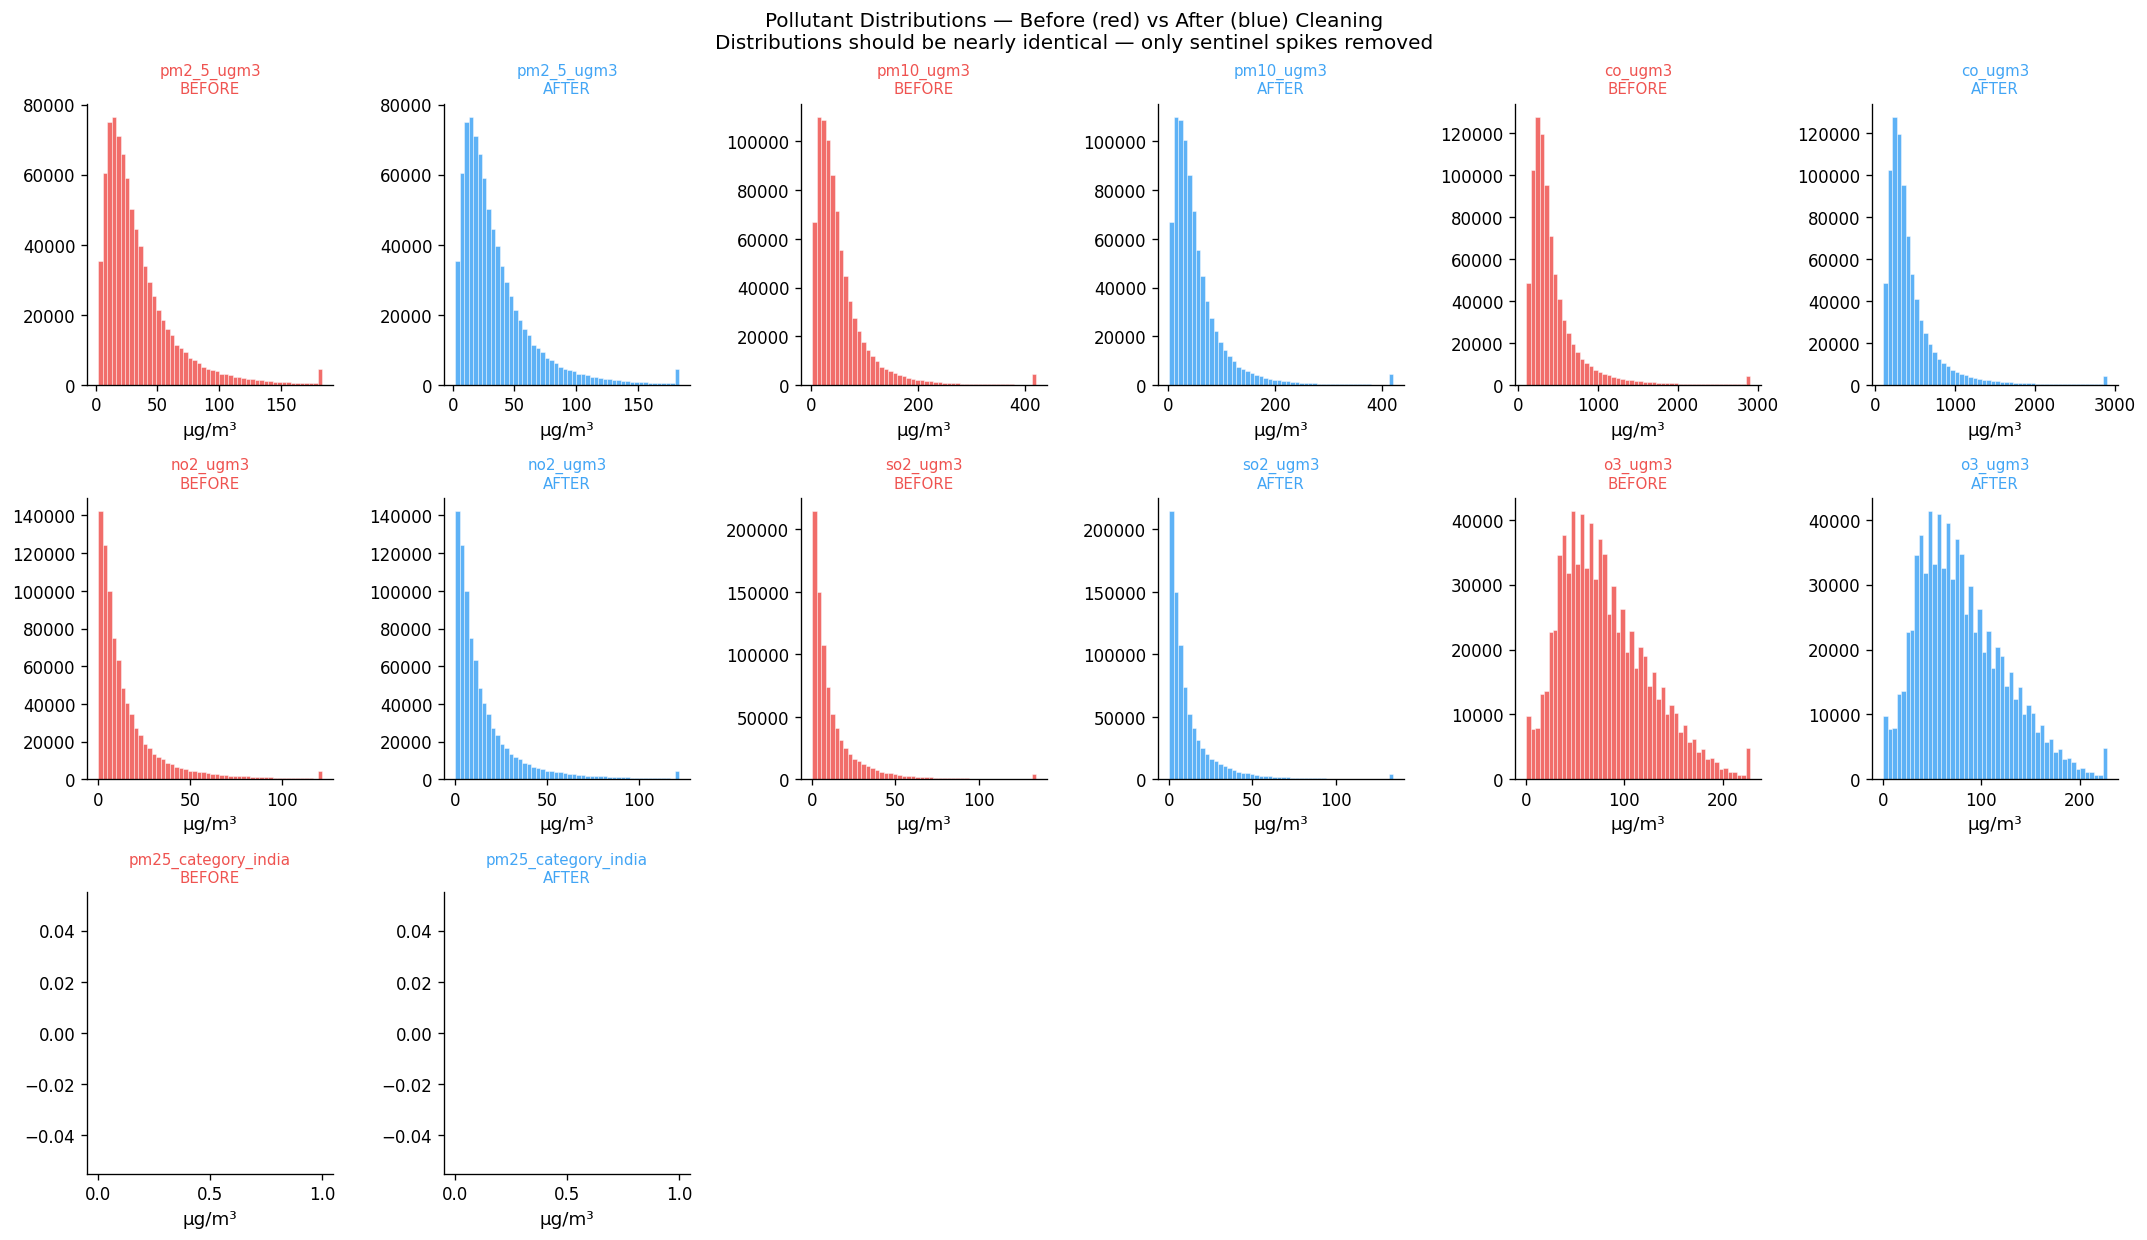

Saved: ./data/cleaned/05_shared/master_cleaned.csv
pyarrow not installed — parquet skipped, CSV is sufficient.
Saved: ./data/cleaned/05_shared/cleaning_log.csv

Master cleaned file ready.
  Rows    : 842,160
  Columns : 35
  Path    : ./data/cleaned/05_shared/master_cleaned.csv


In [17]:
# ── Before vs After distribution comparison ───────────────────────────────────
n     = len(pollutant_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols * 2, figsize=(18, nrows * 3.5))

for i, col in enumerate(pollutant_cols):
    ax_before = axes[i // ncols][(i % ncols) * 2]
    ax_after  = axes[i // ncols][(i % ncols) * 2 + 1]

    raw     = pd.to_numeric(df_raw_snapshot[col], errors='coerce').dropna()
    cleaned = pd.to_numeric(df[col],              errors='coerce').dropna()

    cl     = col.lower()
    ranges = VALID_RANGES_UGM3 if 'ugm3' in cl else VALID_RANGES_MGM3
    _, hi  = next(((lo, hi) for kw, (lo, hi) in ranges.items() if kw in cl), (0, 9999))

    clip = hi
    ax_before.hist(raw[raw <= clip],     bins=50, color='#EF5350',
                   edgecolor='white', linewidth=0.3, alpha=0.85)
    ax_after.hist( cleaned[cleaned <= clip], bins=50, color='#42A5F5',
                   edgecolor='white', linewidth=0.3, alpha=0.85)

    ax_before.set_title(f'{col}\nBEFORE', fontsize=9, color='#EF5350')
    ax_after.set_title( f'{col}\nAFTER',  fontsize=9, color='#42A5F5')
    ax_before.set_xlabel('µg/m³')
    ax_after.set_xlabel('µg/m³')

for j in range(i + 1, nrows * ncols):
    axes[j // ncols][(j % ncols) * 2].set_visible(False)
    axes[j // ncols][(j % ncols) * 2 + 1].set_visible(False)

plt.suptitle(
    'Pollutant Distributions — Before (red) vs After (blue) Cleaning\n'
    'Distributions should be nearly identical — only sentinel spikes removed',
    fontsize=12
)
plt.tight_layout()
plt.show()

# ── Save master cleaned file ──────────────────────────────────────────────────
import os
SHARED_DIR = './data/cleaned/05_shared'
os.makedirs(SHARED_DIR, exist_ok=True)

csv_path = os.path.join(SHARED_DIR, 'master_cleaned.csv')
df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

try:
    parquet_path = os.path.join(SHARED_DIR, 'master_cleaned.parquet')
    df.to_parquet(parquet_path, index=False)
    print(f'Saved: {parquet_path}')
except ImportError:
    print('pyarrow not installed — parquet skipped, CSV is sufficient.')

# Save cleaning log
log_path = os.path.join(SHARED_DIR, 'cleaning_log.csv')
pd.DataFrame(cleaning_log).to_csv(log_path, index=False)
print(f'Saved: {log_path}')

print(f'\nMaster cleaned file ready.')
print(f'  Rows    : {len(df):,}')
print(f'  Columns : {len(df.columns)}')
print(f'  Path    : {csv_path}')

## Feature Encoding

Machine learning models operate exclusively on numbers. The cleaned dataset
contains several columns that are stored as text or categories — `city`,
`season`, `day_name`, `aqi_category`. These must be converted to numeric
representations before any model can use them.

There is no single correct encoding method. The right choice depends on the
column's role in the pipeline and which model will consume it.

### Encoding Methods Used in This Section

| Method | When to Use | Example |
|---|---|---|
| Label Encoding | Categorical column with no natural order, tree-based models | city → 0,1,2...28 |
| Ordinal Encoding | Categorical column with a meaningful order | Good < Satisfactory < Moderate... |
| One-Hot Encoding | Low-cardinality nominal column, linear models | season → 4 binary columns |
| Target Encoding | High-cardinality nominal column, regression | city → mean AQI of that city |

### What Will and Will Not Be Encoded Here

| Column | Encoding | Reason |
|---|---|---|
| `aqi_category` | Ordinal (0–5) | Has a natural pollution severity order |
| `city` | Label + Target | Label for trees, target for regression |
| `season` | Label + One-Hot | Both demonstrated, one-hot explained but not used |
| `day_name` | Label | Weekday/weekend signal for models |

> **Data leakage note:** Encoders are always fit on training data only and
> then applied to test data. Fitting on the full dataset before splitting
> would leak test set statistics into the training process. In this section
> we demonstrate the encodings on the full cleaned dataset for inspection.
> The train-only fitting happens in the regression and classification
> preparation sections that follow.

### Encoding 1 — Ordinal Encoding of AQI Category

`aqi_category` is the classification target. It has six values that follow a
natural severity order:
```
Good(0) < Satisfactory(1) < Moderate(2) < Poor(3) < Very Poor(4) < Severe(5)
```

This order is meaningful and must be preserved. Label encoding would assign
integers arbitrarily (alphabetical or frequency order). Ordinal encoding
explicitly assigns integers in the correct domain order.

The encoded column `aqi_category_enc` will be used as the integer target
variable `y` in all classification models.

ORDINAL ENCODING — aqi_category
  Category           Integer
  ------------------------------
  Good               0   (136,476 rows)
  Satisfactory       1   (0 rows)
  Moderate           2   (385,833 rows)
  Poor               3   (175,125 rows)
  Very Poor          4   (144,726 rows)
  Severe             5   (0 rows)

  Unmapped rows : 0
  Sample check  :
aqi_category  aqi_category_enc
        Good                 0
    Moderate                 2
        Poor                 3
   Very Poor                 4


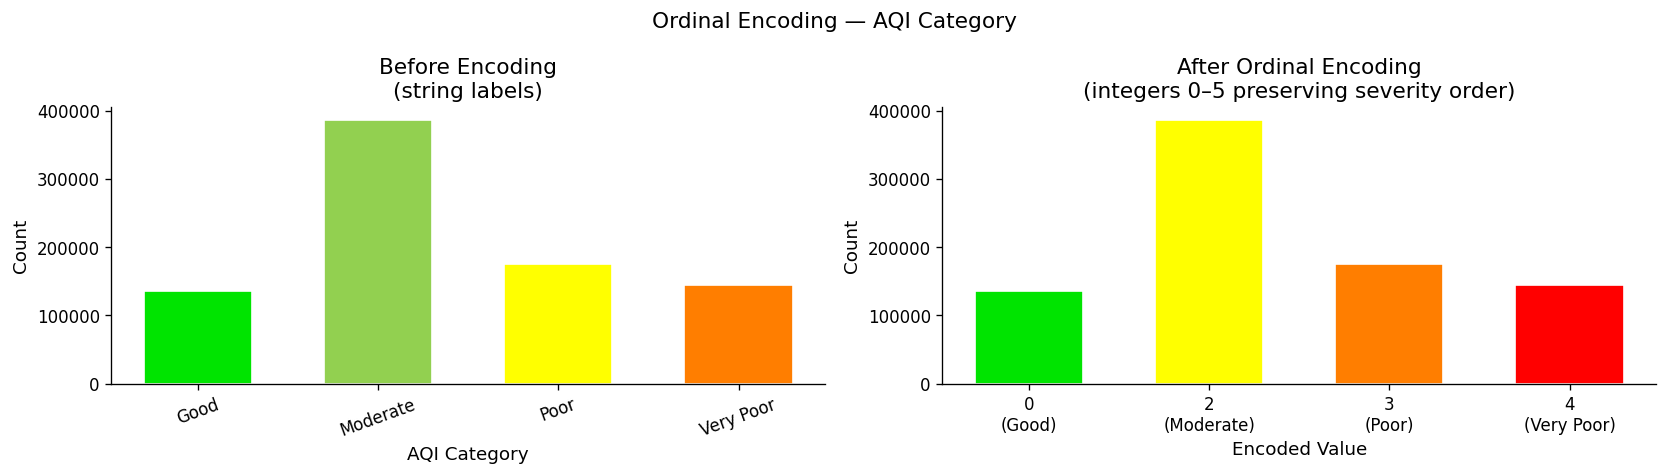

In [20]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Ordinal encoding of AQI category ─────────────────────────────────────────
CAT_ORDER  = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
CAT_COLORS = ['#00E400','#92D050','#FFFF00','#FF7E00','#FF0000','#99004C']

ordinal_map = {cat: i for i, cat in enumerate(CAT_ORDER)}

df['aqi_category_enc'] = df[cat_col].map(ordinal_map)

unmapped = df['aqi_category_enc'].isnull().sum()

print('ORDINAL ENCODING — aqi_category')
print(f'{"="*45}')
print(f'  {"Category":<18} {"Integer"}')
print(f'  {"-"*30}')
for cat, val in ordinal_map.items():
    count = (df[cat_col] == cat).sum()
    print(f'  {cat:<18} {val}   ({count:,} rows)')

print(f'\n  Unmapped rows : {unmapped:,}')
print(f'  Sample check  :')
print(df[[cat_col, 'aqi_category_enc']].drop_duplicates()
      .sort_values('aqi_category_enc').to_string(index=False))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: original string distribution
counts = df[cat_col].value_counts().reindex(CAT_ORDER).dropna()
axes[0].bar(counts.index, counts.values,
            color=CAT_COLORS[:len(counts)], edgecolor='white', width=0.6)
axes[0].set_title('Before Encoding\n(string labels)')
axes[0].set_xlabel('AQI Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

# Right: encoded integer distribution
enc_counts = df['aqi_category_enc'].value_counts().sort_index()
axes[1].bar(
    [f'{i}\n({CAT_ORDER[i]})' for i in enc_counts.index],
    enc_counts.values,
    color=[CAT_COLORS[i] for i in enc_counts.index],
    edgecolor='white', width=0.6
)
axes[1].set_title('After Ordinal Encoding\n(integers 0–5 preserving severity order)')
axes[1].set_xlabel('Encoded Value')
axes[1].set_ylabel('Count')

plt.suptitle('Ordinal Encoding — AQI Category', fontsize=13)
plt.tight_layout()
plt.show()

### Encoding 2 — Label Encoding of City and Season

**City:** 29 cities are mapped to integers 0–28 alphabetically. This encoding
is used for tree-based models (Decision Trees, Random Forest, KNN) where the
model learns thresholds on the encoded integer. These models do not assume any
numeric relationship between the integers — city 9 (Delhi) being larger than
city 2 (Aizawl) does not imply Delhi is "more" of anything.

**Season:** Four seasons mapped to integers 0–3. Used as a lightweight
alternative to one-hot encoding when the model can handle ordinal-style
categoricals.

**Day name:** Monday through Sunday mapped to integers. Captures the
weekly industrial and traffic cycle — weekdays vs weekends produce
measurably different pollution signatures.

LABEL ENCODING — city
              city  city_enc
          agartala         0
         ahmedabad         1
            aizawl         2
         bengaluru         3
            bhopal         4
       bhubaneswar         5
        chandigarh         6
           chennai         7
          dehradun         8
             delhi         9
           gangtok        10
          gurugram        11
          guwahati        12
         hyderabad        13
            imphal        14
          itanagar        15
            jaipur        16
            kohima        17
           kolkata        18
           lucknow        19
            mumbai        20
            panaji        21
             patna        22
            raipur        23
            ranchi        24
          shillong        25
            shimla        26
thiruvananthapuram        27
     visakhapatnam        28

LABEL ENCODING — season
  0  ->  monsoon
  1  ->  post_monsoon
  2  ->  summer
  3  ->  winter

LABEL ENCOD

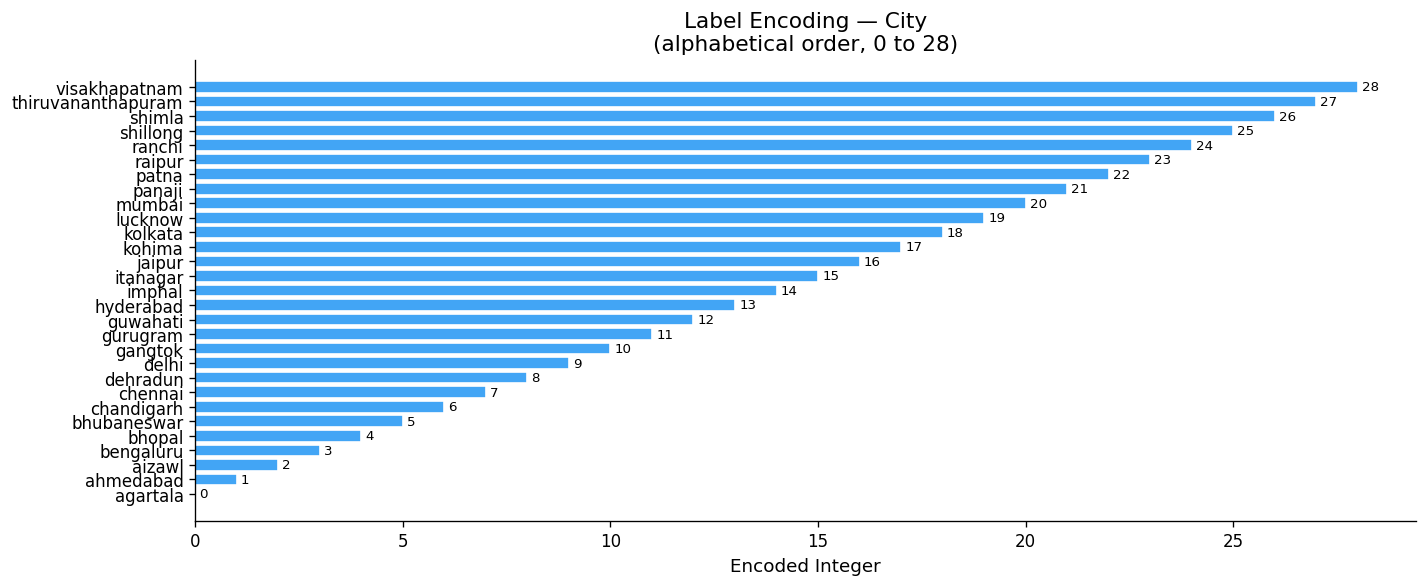

In [21]:
# ── Label encoding ────────────────────────────────────────────────────────────
le_city   = LabelEncoder()
le_season = LabelEncoder()
le_day    = LabelEncoder()

df['city_enc']    = le_city.fit_transform(df[city_col].astype(str))
df['season_enc']  = le_season.fit_transform(df['season'].astype(str)) \
                    if 'season' in df.columns else np.nan
df['day_enc']     = le_day.fit_transform(df['day_name'].astype(str)) \
                    if 'day_name' in df.columns else np.nan

# ── City mapping table ────────────────────────────────────────────────────────
city_mapping = pd.DataFrame({
    'city'    : le_city.classes_,
    'city_enc': range(len(le_city.classes_))
})

print('LABEL ENCODING — city')
print(f'{"="*40}')
print(city_mapping.to_string(index=False))

# ── Season mapping ────────────────────────────────────────────────────────────
if 'season' in df.columns:
    print(f'\nLABEL ENCODING — season')
    print(f'{"="*40}')
    for enc, label in enumerate(le_season.classes_):
        print(f'  {enc}  ->  {label}')

# ── Day mapping ───────────────────────────────────────────────────────────────
if 'day_name' in df.columns:
    print(f'\nLABEL ENCODING — day_name')
    print(f'{"="*40}')
    for enc, label in enumerate(le_day.classes_):
        print(f'  {enc}  ->  {label}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
city_enc_counts = df.groupby('city_enc')[city_col].first().reset_index()
city_enc_counts = city_enc_counts.sort_values('city_enc')

bars = ax.barh(
    city_enc_counts[city_col],
    city_enc_counts['city_enc'],
    color='#42A5F5', edgecolor='white'
)
for bar, val in zip(bars, city_enc_counts['city_enc']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8)

ax.set_xlabel('Encoded Integer')
ax.set_title('Label Encoding — City\n(alphabetical order, 0 to 28)')
plt.tight_layout()
plt.show()

### Encoding 3 — One-Hot Encoding (Demonstrated, Not Used for City)

One-hot encoding creates one binary column per category value. For a column
with N unique values, it produces N new columns where exactly one is 1 for
any given row.

**Why we demonstrate it but do not use it for city:**

City has 29 unique values. One-hot encoding would add 29 new columns to the
feature matrix — one for each city. This creates two problems:

1. **Dimensionality:** 29 extra binary columns increase memory and training
   time with minimal benefit over label encoding for tree-based models.

2. **Multicollinearity:** In linear regression, 29 dummy columns for a
   single variable are perfectly collinear — knowing 28 of them tells you
   the 29th. This is called the dummy variable trap and is fixed by dropping
   one column (`drop_first=True`), but this makes coefficient interpretation
   awkward.

One-hot encoding is appropriate for season (4 values) and time_of_day
(4 values) when used with linear regression, where the model cannot handle
ordinal assumptions between categories.

ONE-HOT ENCODING — season (demonstration)
  Original column  : season (4 unique values)
  Columns created  : ['season_monsoon', 'season_post_monsoon', 'season_summer', 'season_winter']

  Sample (first 8 rows):


,season,season_monsoon,season_post_monsoon,season_summer,season_winter
0,monsoon,1,0,0,0
1,monsoon,1,0,0,0
2,monsoon,1,0,0,0
3,monsoon,1,0,0,0
4,monsoon,1,0,0,0
5,monsoon,1,0,0,0
6,monsoon,1,0,0,0
7,monsoon,1,0,0,0



  Why drop_first matters for linear regression:
  With drop_first=False : 4 columns — dummy variable trap
  With drop_first=True  : 3 columns — safe for linear regression
  Dropped reference category: Winter (absorbed into intercept)


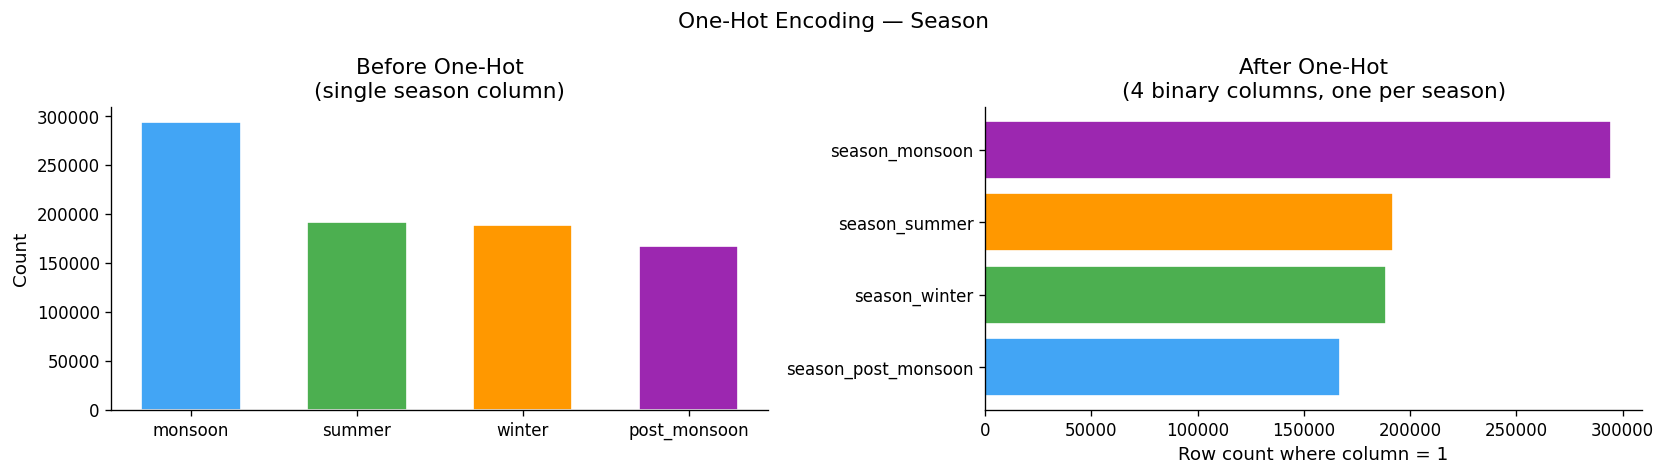


Note: season_ohe columns are NOT added to df permanently.
They will be included only in the regression feature matrix
where linear models require them.


In [22]:
# ── One-hot encoding — demonstrated on season ─────────────────────────────────
season_ohe = pd.get_dummies(
    df['season'],
    prefix='season',
    drop_first=False,   # keep all for inspection
    dtype=int
)

print('ONE-HOT ENCODING — season (demonstration)')
print(f'{"="*55}')
print(f'  Original column  : season ({df["season"].nunique()} unique values)')
print(f'  Columns created  : {list(season_ohe.columns)}')
print(f'\n  Sample (first 8 rows):')
display(pd.concat([df['season'].head(8), season_ohe.head(8)], axis=1))

print(f'\n  Why drop_first matters for linear regression:')
print(f'  With drop_first=False : {season_ohe.shape[1]} columns — dummy variable trap')
season_ohe_dropped = pd.get_dummies(df['season'], prefix='season',
                                    drop_first=True, dtype=int)
print(f'  With drop_first=True  : {season_ohe_dropped.shape[1]} columns — safe for linear regression')
print(f'  Dropped reference category: Winter (absorbed into intercept)')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: original season
season_counts = df['season'].value_counts()
axes[0].bar(season_counts.index, season_counts.values,
            color=['#42A5F5','#4CAF50','#FF9800','#9C27B0'],
            edgecolor='white', width=0.6)
axes[0].set_title('Before One-Hot\n(single season column)')
axes[0].set_ylabel('Count')

# Right: after one-hot
ohe_sums = season_ohe.sum().sort_values(ascending=True)
axes[1].barh(ohe_sums.index, ohe_sums.values,
             color=['#42A5F5','#4CAF50','#FF9800','#9C27B0'],
             edgecolor='white')
axes[1].set_title('After One-Hot\n(4 binary columns, one per season)')
axes[1].set_xlabel('Row count where column = 1')

plt.suptitle('One-Hot Encoding — Season', fontsize=13)
plt.tight_layout()
plt.show()

print('\nNote: season_ohe columns are NOT added to df permanently.')
print('They will be included only in the regression feature matrix')
print('where linear models require them.')

### Encoding 4 — Target Encoding of City

Target encoding replaces each category value with the mean of the target
variable for that category. For city, it computes the mean AQI for each
of the 29 cities across all rows and substitutes that mean wherever that
city appears.
```
city_target_enc(Delhi) = mean(AQI of all Delhi rows)
city_target_enc(Aizawl) = mean(AQI of all Aizawl rows)
```

**Advantage over label encoding for regression:** Target encoding carries
real predictive signal — a city encoded as 287 (mean AQI) directly tells
the regression model that this city tends to be highly polluted. Label
encoding carries no such signal (Delhi = 9 is arbitrary).

**Risk — data leakage:** If you compute mean AQI using the full dataset
including test rows, the test set's pollution levels have influenced the
encoding. This is leakage. The correct approach is to compute target
encoding means from training rows only and apply them to test rows.
This is handled properly in the regression preparation section.

Here we compute it on the full dataset for inspection and visualisation only.

TARGET ENCODING — city (using mean aqi_category_enc as proxy)
  City                       Mean AQI Category Enc
  --------------------------------------------------
  gurugram                                   3.538  ███████████████████████████████████
  delhi                                      3.491  ██████████████████████████████████
  patna                                      3.146  ███████████████████████████████
  lucknow                                    3.080  ██████████████████████████████
  raipur                                     3.009  ██████████████████████████████
  kolkata                                    2.868  ████████████████████████████
  chandigarh                                 2.818  ████████████████████████████
  mumbai                                     2.748  ███████████████████████████
  visakhapatnam                              2.590  █████████████████████████
  jaipur                                     2.588  █████████████████████████
  bhubanesw

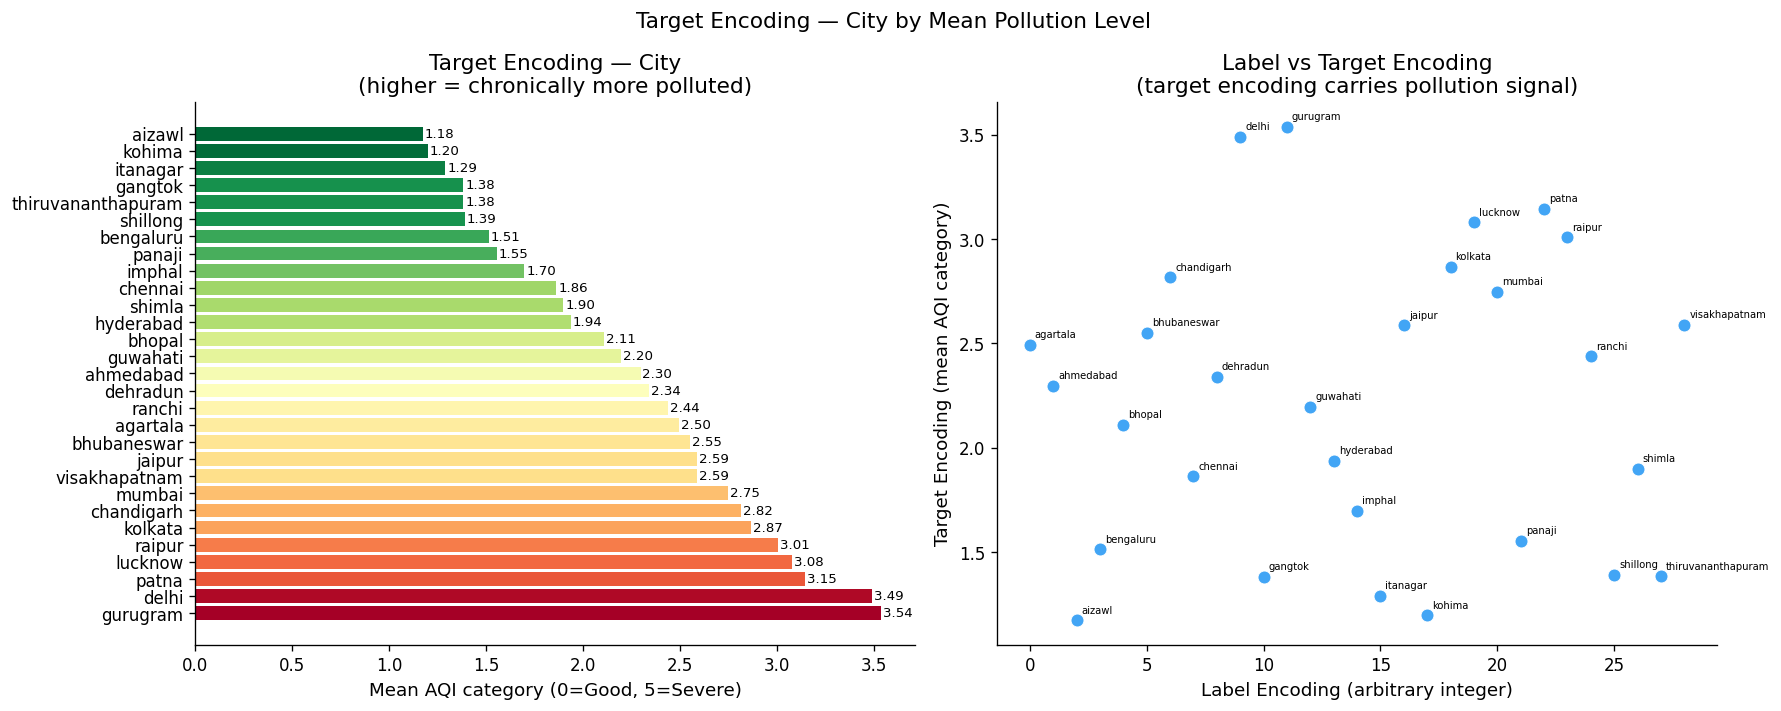


  ENCODING SUMMARY — NEW COLUMNS ADDED TO df
  aqi_category_enc       dtype=int64      nulls=0      sample=4
  city_enc               dtype=int64      nulls=0      sample=0
  season_enc             dtype=int64      nulls=0      sample=0
  day_enc                dtype=int64      nulls=0      sample=0
  city_target_enc        dtype=float64    nulls=0      sample=2.495


In [23]:
# ── Target encoding of city using computed AQI ───────────────────────────────
# Use aqi_category_enc as proxy if numeric AQI not yet computed
target_col_for_enc = 'aqi_category_enc'

city_target_means = (
    df.groupby(city_col)[target_col_for_enc]
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

df['city_target_enc'] = df[city_col].map(city_target_means)

print('TARGET ENCODING — city (using mean aqi_category_enc as proxy)')
print(f'{"="*55}')
print(f'  {"City":<25} {"Mean AQI Category Enc":>22}')
print(f'  {"-"*50}')
for city, mean_val in city_target_means.items():
    bar = '█' * int(mean_val * 10)
    print(f'  {city:<25} {mean_val:>22.3f}  {bar}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: target encoded value per city
colors_te = plt.cm.RdYlGn_r(
    (city_target_means.values - city_target_means.min()) /
    (city_target_means.max() - city_target_means.min())
)
bars = axes[0].barh(city_target_means.index, city_target_means.values,
                    color=colors_te)
axes[0].set_xlabel('Mean AQI category (0=Good, 5=Severe)')
axes[0].set_title('Target Encoding — City\n(higher = chronically more polluted)')
for bar, val in zip(bars, city_target_means.values):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=8)

# Right: label enc vs target enc scatter
enc_compare = df.groupby(city_col).agg(
    label_enc  = ('city_enc', 'first'),
    target_enc = ('city_target_enc', 'first')
).reset_index()

axes[1].scatter(enc_compare['label_enc'], enc_compare['target_enc'],
                color='#42A5F5', s=60, edgecolors='white', linewidths=0.5)
for _, row in enc_compare.iterrows():
    axes[1].annotate(row[city_col],
                     (row['label_enc'], row['target_enc']),
                     fontsize=6, ha='left', va='bottom',
                     xytext=(3, 3), textcoords='offset points')
axes[1].set_xlabel('Label Encoding (arbitrary integer)')
axes[1].set_ylabel('Target Encoding (mean AQI category)')
axes[1].set_title('Label vs Target Encoding\n(target encoding carries pollution signal)')

plt.suptitle('Target Encoding — City by Mean Pollution Level', fontsize=13)
plt.tight_layout()
plt.show()

# ── Encoding summary ──────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print('  ENCODING SUMMARY — NEW COLUMNS ADDED TO df')
print(f'{"="*60}')
new_cols = ['aqi_category_enc', 'city_enc', 'season_enc',
            'day_enc', 'city_target_enc']
for col in new_cols:
    if col in df.columns:
        dtype   = df[col].dtype
        nulls   = df[col].isnull().sum()
        sample  = df[col].dropna().iloc[0]
        print(f'  {col:<22} dtype={str(dtype):<10} '
              f'nulls={nulls:<6} sample={sample}')

## Feature Selection

After encoding, the dataset has a large number of candidate columns. Not all
of them should go into a model. Including irrelevant or redundant features
causes three specific problems:

1. **Multicollinearity** — two highly correlated features carry the same
   information but confuse the regression coefficient estimates
2. **Noise** — features with no relationship to the target add variance
   to predictions without adding signal
3. **Overfitting** — too many features relative to the number of meaningful
   patterns causes the model to memorise training data rather than generalise

Feature selection answers one question: **which columns actually help predict
the target, and which are redundant or irrelevant?**

### Methods Used in This Section

| Method | Type | What It Measures |
|---|---|---|
| Pearson Correlation | Filter | Linear relationship between each feature and target |
| Mutual Information | Filter | Any relationship — linear or non-linear |
| ANOVA F-test | Filter | Variance explained by each feature for regression |
| Variance Inflation Factor | Multicollinearity | How much each feature is explained by other features |
| Recursive Feature Elimination | Wrapper | Which subset of features a linear model performs best with |
| Random Forest Importance | Embedded | Which features a forest uses most for splitting |

Filter methods evaluate each feature independently and are fast.
Wrapper methods evaluate feature subsets using a model and are slower but
more accurate. Embedded methods learn importance during model training.

Using multiple methods and looking for agreement across them produces a
more reliable final feature set than relying on any single method alone.

### Method 1 — Pearson Correlation Filter

Pearson correlation measures the linear relationship between each feature
and the target variable. It ranges from -1 to +1.

A common threshold is |r| > 0.1 as a minimum bar for inclusion. Features
below this threshold have essentially no linear relationship with the target
and are unlikely to contribute to a linear regression model.

**Limitation:** Pearson only captures linear relationships. A feature that
has a strong non-linear relationship with the target (for example, O3 which
follows a parabolic daily cycle) may show a low Pearson r but still be a
useful predictor. This is why we use multiple methods.

Feature selection setup:
  Candidate features : 12
  Available (no NaN) : 12
  Rows used          : 842,160
  Target             : aqi_category_enc

PEARSON CORRELATION WITH TARGET (|r|):
  pm2_5_ugm3             0.7131  █████████████████████
  pm10_ugm3              0.6195  ██████████████████
  city_target_enc        0.5642  ████████████████
  co_ugm3                0.4986  ██████████████
  so2_ugm3               0.4666  █████████████
  no2_ugm3               0.4133  ████████████
  season_enc             0.3818  ███████████
  o3_ugm3                0.2920  ████████
  month                  0.1562  ████
  hour                   0.0318    <- weak, consider dropping
  city_enc               0.0139    <- weak, consider dropping
  day_of_week            0.0036    <- weak, consider dropping

Selected (|r| >= 0.05) : ['pm2_5_ugm3', 'pm10_ugm3', 'city_target_enc', 'co_ugm3', 'so2_ugm3', 'no2_ugm3', 'season_enc', 'o3_ugm3', 'month']


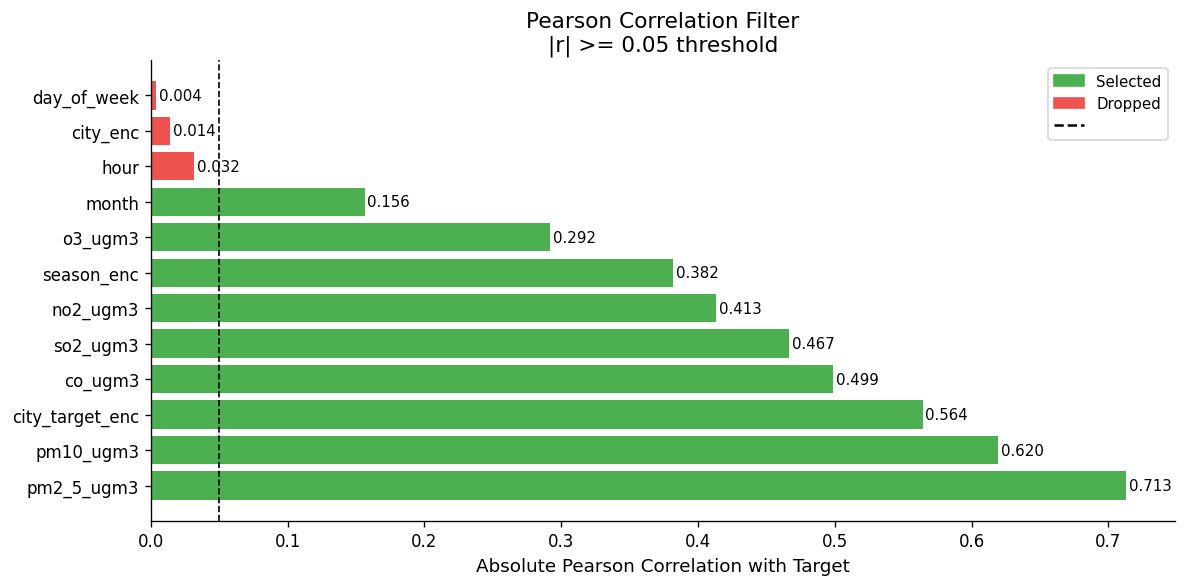

In [24]:
from sklearn.feature_selection import mutual_info_regression, f_classif, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# ── Define candidate features and target ──────────────────────────────────────
CANDIDATE_FEATURES = [
    'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3',
    'city_enc', 'city_target_enc',
    'month', 'hour', 'day_of_week', 'season_enc',
]

# Use aqi_category_enc as regression proxy target
# (numeric AQI computed in next section — use ordinal enc for selection)
TARGET = 'aqi_category_enc'

# Keep only features that exist and have no NaN
available = [
    f for f in CANDIDATE_FEATURES
    if f in df.columns and df[f].isnull().sum() == 0
]

df_fs   = df[available + [TARGET]].dropna().copy()
X_fs    = df_fs[available]
y_fs    = df_fs[TARGET]

print(f'Feature selection setup:')
print(f'  Candidate features : {len(CANDIDATE_FEATURES)}')
print(f'  Available (no NaN) : {len(available)}')
print(f'  Rows used          : {len(df_fs):,}')
print(f'  Target             : {TARGET}')

# ── Pearson correlation ───────────────────────────────────────────────────────
pearson_corr = X_fs.corrwith(y_fs).abs().sort_values(ascending=False)

print(f'\nPEARSON CORRELATION WITH TARGET (|r|):')
print(f'{"="*45}')
for feat, val in pearson_corr.items():
    bar    = '█' * int(val * 30)
    flag   = '  <- weak, consider dropping' if val < 0.05 else ''
    print(f'  {feat:<22} {val:.4f}  {bar}{flag}')

pearson_selected = pearson_corr[pearson_corr >= 0.05].index.tolist()
print(f'\nSelected (|r| >= 0.05) : {pearson_selected}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4CAF50' if v >= 0.05 else '#EF5350' for v in pearson_corr.values]
bars   = ax.barh(pearson_corr.index, pearson_corr.values, color=colors)
ax.axvline(0.05, color='black', linestyle='--',
           linewidth=1, label='Threshold: |r| = 0.05')
for bar, val in zip(bars, pearson_corr.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
green_p = mpatches.Patch(color='#4CAF50', label='Selected')
red_p   = mpatches.Patch(color='#EF5350', label='Dropped')
ax.legend(handles=[green_p, red_p, plt.Line2D([0],[0],
          color='black', linestyle='--')], fontsize=9)
ax.set_xlabel('Absolute Pearson Correlation with Target')
ax.set_title('Pearson Correlation Filter\n|r| >= 0.05 threshold')
plt.tight_layout()
plt.show()

### Method 2 — Mutual Information

Mutual information measures how much knowing a feature reduces uncertainty
about the target. Unlike Pearson correlation, it captures non-linear
relationships.

A mutual information score of 0 means the feature and target are completely
independent. Higher scores indicate stronger dependency, but the scale is
not bounded like correlation — scores must be interpreted relative to each
other rather than against a fixed threshold.

Mutual information is particularly useful for catching features like `hour`
and `season` which have a cyclical, non-linear relationship with AQI
that Pearson underestimates.

In [ ]:
# ── Mutual information ────────────────────────────────────────────────────────
mi_scores = mutual_info_regression(X_fs, y_fs, random_state=42)
mi_series = pd.Series(mi_scores, index=available).sort_values(ascending=False)

print('MUTUAL INFORMATION SCORES:')
print(f'{"="*45}')
for feat, val in mi_series.items():
    bar  = '█' * int(val * 20)
    flag = '  <- near zero, likely irrelevant' if val < 0.01 else ''
    print(f'  {feat:<22} {val:.4f}  {bar}{flag}')

mi_selected = mi_series[mi_series >= 0.01].index.tolist()
print(f'\nSelected (MI >= 0.01) : {mi_selected}')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#4CAF50' if v >= 0.01 else '#EF5350' for v in mi_series.values]
bars    = ax.barh(mi_series.index, mi_series.values, color=colors)
ax.axvline(0.01, color='black', linestyle='--',
           linewidth=1, label='Threshold: MI = 0.01')
for bar, val in zip(bars, mi_series.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
green_p = mpatches.Patch(color='#4CAF50', label='Selected')
red_p   = mpatches.Patch(color='#EF5350', label='Dropped')
ax.legend(handles=[green_p, red_p], fontsize=9)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information Filter\nCaptures non-linear relationships Pearson misses')
plt.tight_layout()
plt.show()